# Deep Kernel Pairwise GP PTO Results Analysis

For **DeepKernelPairwiseGP**: https://github.com/yongtaoliu/DKGP.git

Developed by **Yongtao Liu**; youngtaoliu@gmail.com; 

https://scholar.google.com/citations?user=V9FMPgQAAAAJ&hl=en

### Imports

In [1]:

import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import mean_squared_error as mse
from scipy.stats import spearmanr
import seaborn as sns
# from utils import get_grid_coords, get_subimages

# Set publication-quality plot defaults
# plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial']
rcParams['font.size'] = 11
rcParams['axes.labelsize'] = 12
rcParams['axes.titlesize'] = 13
rcParams['xtick.labelsize'] = 10
rcParams['ytick.labelsize'] = 10
rcParams['legend.fontsize'] = 15
rcParams['figure.titlesize'] = 14
# rcParams['axes.spines.top'] = False
# rcParams['axes.spines.right'] = False


### Load Data

BEPS (Band Excitation Piezoresponse Spectroscopy) measures ferroelectric properties:
- **Amplitude** (`amp_off_field`): Piezoelectric response strength
- **Phase** (`pha_off_field`): Response phase
- **Piezoresponse**: Hysteresis loops showing ferroelectric switching

In [2]:
## Helper function

"""The loop area of the hysteresis curve is related to:
 --Strength of ferroelectric switching
 --Energy dissipation during polarization reversal
 --Quality of the ferroelectric material at that location"""

def loop_area(raw_spec, cycle):
    """Calculate loop area from spectrum."""
    raw_spec_len = len(raw_spec)
    cycle_len = int(raw_spec_len / cycle)
    half_len = int(cycle_len / 2)
    q_len = int(cycle_len / 4)
    loop_top, loop_bottom = [], []
    loop_top.append(raw_spec[q_len : q_len + half_len])
    loop_top.append(raw_spec[q_len + 2*half_len : q_len + 3*half_len])
    loop_top.append(raw_spec[q_len + 4*half_len : 2*q_len + 4*half_len])
    loop_bottom.append(raw_spec[:q_len])
    loop_bottom.append(raw_spec[q_len + half_len: q_len + 2*half_len])
    loop_bottom.append(raw_spec[q_len + 3*half_len: q_len + 4*half_len])
    loop_top = np.concatenate(loop_top)
    loop_bottom = np.concatenate(loop_bottom)
    return np.abs(np.sum(loop_top) - np.sum(loop_bottom))

norm_ = lambda x: (x - x.min()) / np.ptp(x)

In [3]:
# Load BEPS data
bepsdata = np.load('PTO_BEPS_3um.npz')
print(f"Available data: {bepsdata.files}")

Available data: ['Image_Amplitude', 'Image_Phase', 'Image_Frequency', 'Image_Q_Factor', 'Image_Off_Field_Loop_Area', 'Image_On_Field_Loop_Area', 'Image_Loop_Width', 'Image_Average_Coercive_Field', 'Image_Negative_Coercive_Field', 'Image_Positive_Coercive_Field', 'Spectra_DC_Voltage', 'Spectra_Off_Field_Loop', 'Spectra_On_Field_Loop', 'Spectra_On_Field_Frequency_Loop', 'Spectra_Off_Field_Frequency_Loop']


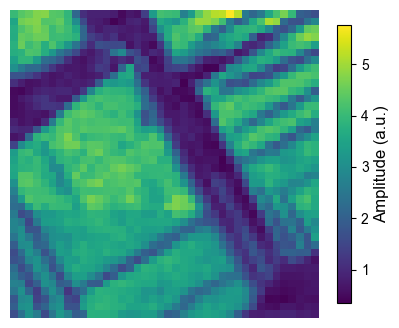

In [4]:
# Extract region of interest
x_cut1 = 20; x_cut2 = 60
y_cut1 = 0; y_cut2 = 40

exp_data = bepsdata['Spectra_Off_Field_Loop'][x_cut1:x_cut2, y_cut1:y_cut2]
struc_img = bepsdata['Image_Amplitude'][x_cut1:x_cut2, y_cut1:y_cut2]
v_step = bepsdata['Spectra_DC_Voltage']

plt.figure(figsize=(5, 4))
plt.imshow(struc_img*1e4, cmap='viridis', origin='lower')
plt.colorbar(label='Amplitude (a.u.)', shrink=0.9)
plt.axis('off')
plt.show()


Text(0, 0.5, 'Polarization (a.u.)')

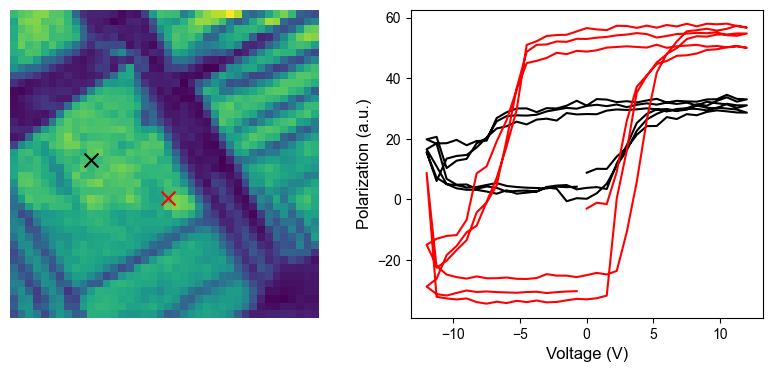

In [5]:
# Visualize
plot_pixx1, plot_pixy1 = 10, 20
plot_pixx2, plot_pixy2 = 20, 15

f, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
a=ax1.imshow(struc_img, origin = "lower")
ax1.scatter(plot_pixx1, plot_pixy1, marker='x', s=100, c='k')
ax1.scatter(plot_pixx2, plot_pixy2, marker='x', s=100, c='r')
# ax1.set_title('Structure Image')
ax1.axis("off")

ax2.plot(v_step, exp_data[plot_pixx1, plot_pixy1], c='k')
ax2.plot(v_step, exp_data[plot_pixx2, plot_pixy2], c='r')
ax2.set_xlabel('Voltage (V)')
ax2.set_ylabel('Polarization (a.u.)')

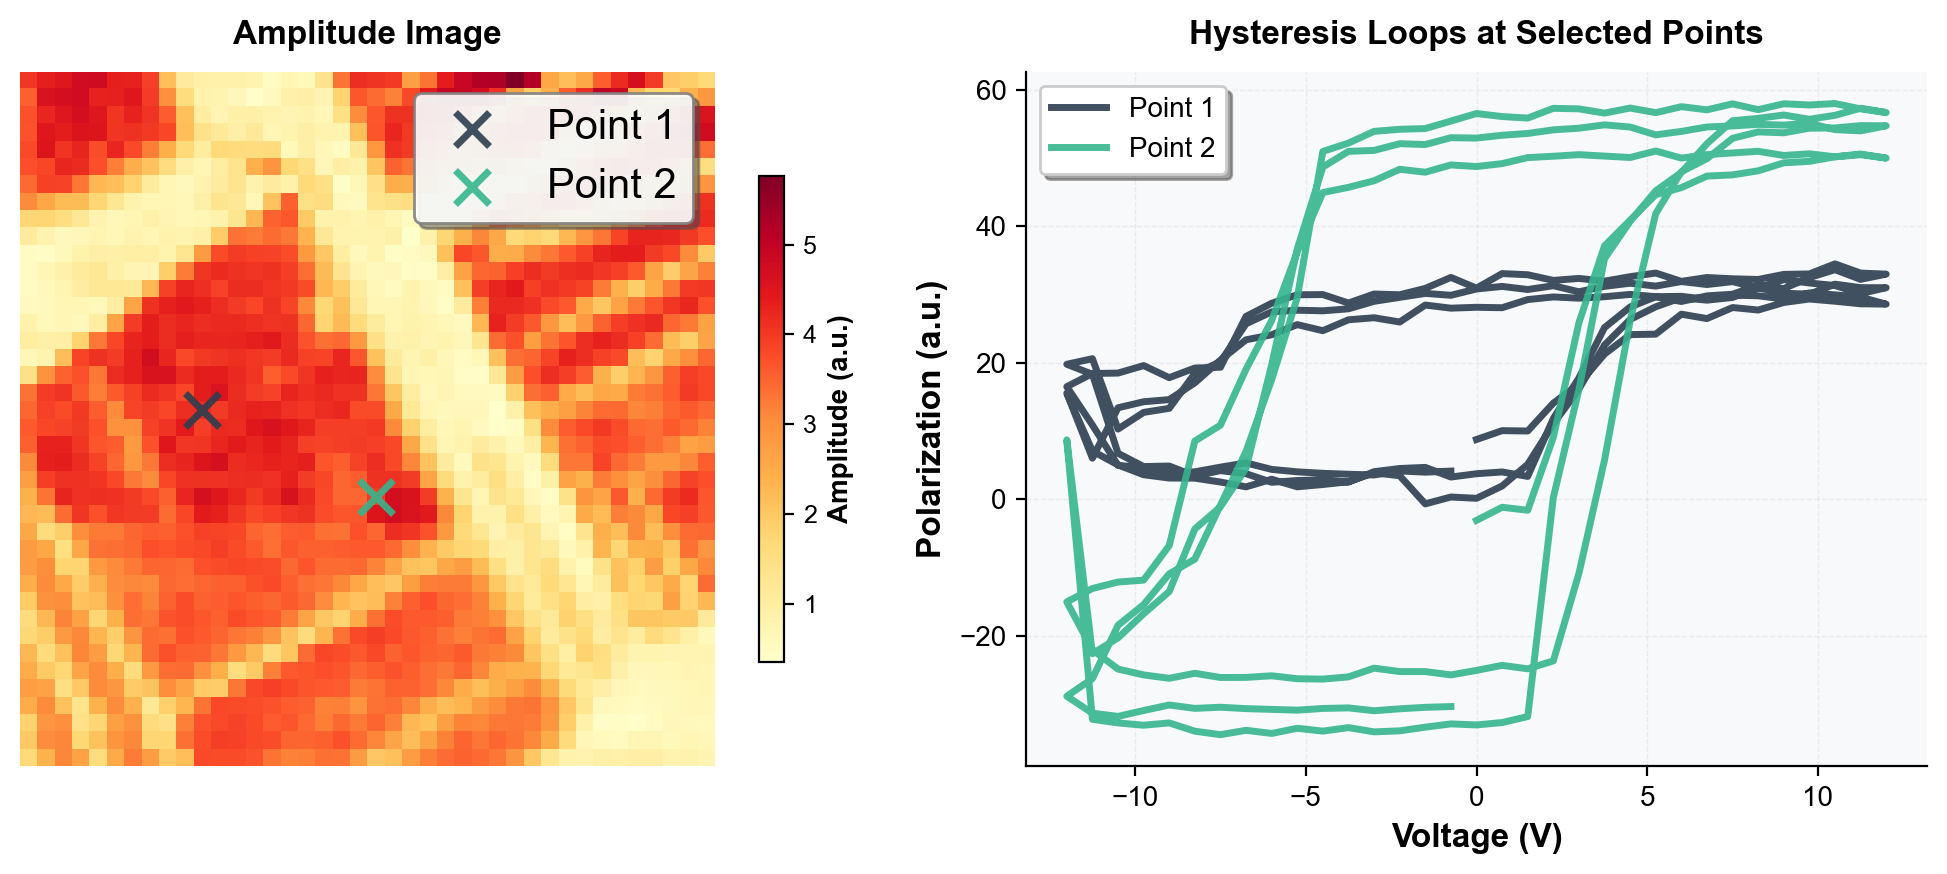

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.5), dpi=200)

# Left panel: Structure image with marked points
im = ax1.imshow(struc_img*1e4, origin="lower", cmap='YlOrRd')
ax1.scatter(plot_pixx1, plot_pixy1, marker='x', s=150, c='#2C3E50', 
            linewidths=2.5, label='Point 1', alpha=0.9)
ax1.scatter(plot_pixx2, plot_pixy2, marker='x', s=150, c="#35B58D", 
            linewidths=2.5, label='Point 2', alpha=0.9)
ax1.set_title('Amplitude Image', fontweight='bold', fontsize=12, pad=10)
ax1.legend(loc='upper right', frameon=True, fancybox=True, shadow=True, 
           facecolor='white', edgecolor='gray', framealpha=0.9)
ax1.axis("off")
# Add colorbar to ax1
cbar1 = plt.colorbar(im, ax=ax1, shrink=0.7)
cbar1.set_label('Amplitude (a.u.)', fontweight='bold', fontsize=10)
cbar1.ax.tick_params(labelsize=9)

# Right panel: Polarization curves
ax2.plot(v_step, exp_data[plot_pixx1, plot_pixy1], 
         color='#2C3E50', linewidth=2.5, label='Point 1', alpha=0.9)
ax2.plot(v_step, exp_data[plot_pixx2, plot_pixy2], 
         color="#35B58D", linewidth=2.5, label='Point 2', alpha=0.9)
ax2.set_xlabel('Voltage (V)', fontweight='bold', fontsize=12)
ax2.set_ylabel('Polarization (a.u.)', fontweight='bold', fontsize=12)
ax2.set_title('Hysteresis Loops at Selected Points', fontweight='bold', fontsize=12, pad=10)
ax2.legend(frameon=True, fancybox=True, shadow=True, loc='best', fontsize=10)
ax2.grid(True, alpha=0.2, linestyle='--', linewidth=0.5)
ax2.set_facecolor('#F8F9FA')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Prepare Training 

- `features_all`: Image patches (n_samples, window_size, window_size)
- `coords`: Center coordinates of each patch (n_samples, 2)
- `targets`: Spectroscopy data at each location (n_samples, n_voltages)
- `loop_areas_all`: Calculated loop area for each location (n_samples,)

In [7]:
from dkgp.utils import get_grid_coords, get_subimages

# Extract image patches and spectra
img = norm_(struc_img)
spectra = norm_(exp_data)

coordinates = get_grid_coords(img, step=1)
window_size = 8
features_all, coords, _ = get_subimages(img, coordinates, window_size)
features_all = features_all[:,:,:,0]
coords = np.array(coords, dtype=int)
targets = spectra[coords[:, 0], coords[:, 1]]

print('Coordinates shape:', coords.shape)
print('Image patches shape:', features_all.shape)
print('Spectra shape:', spectra.shape)
print('Target spectra shape:', targets.shape)

np.savez("expdata.npz", img = norm_(struc_img), spectra=norm_(exp_data))

/Users/yla/ORNL Dropbox/Yongtao Liu/MyFiles/CNMS_2025/Manuscripts/Workingon/DKLPairwiseGP/PTO_tie/.venv/lib/python3.14/site-packages/pyro/ops/stats.py:527: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
  we have :math:`ES^{*}(P,Q) \ge ES^{*}(Q,Q)` with equality holding if and only if :math:`P=Q`, i.e.
/Users/yla/ORNL Dropbox/Yongtao Liu/MyFiles/CNMS_2025/Manuscripts/Workingon/DKLPairwiseGP/PTO_tie/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Coordinates shape: (1089, 2)
Image patches shape: (1089, 8, 8)
Spectra shape: (40, 40, 192)
Target spectra shape: (1089, 192)


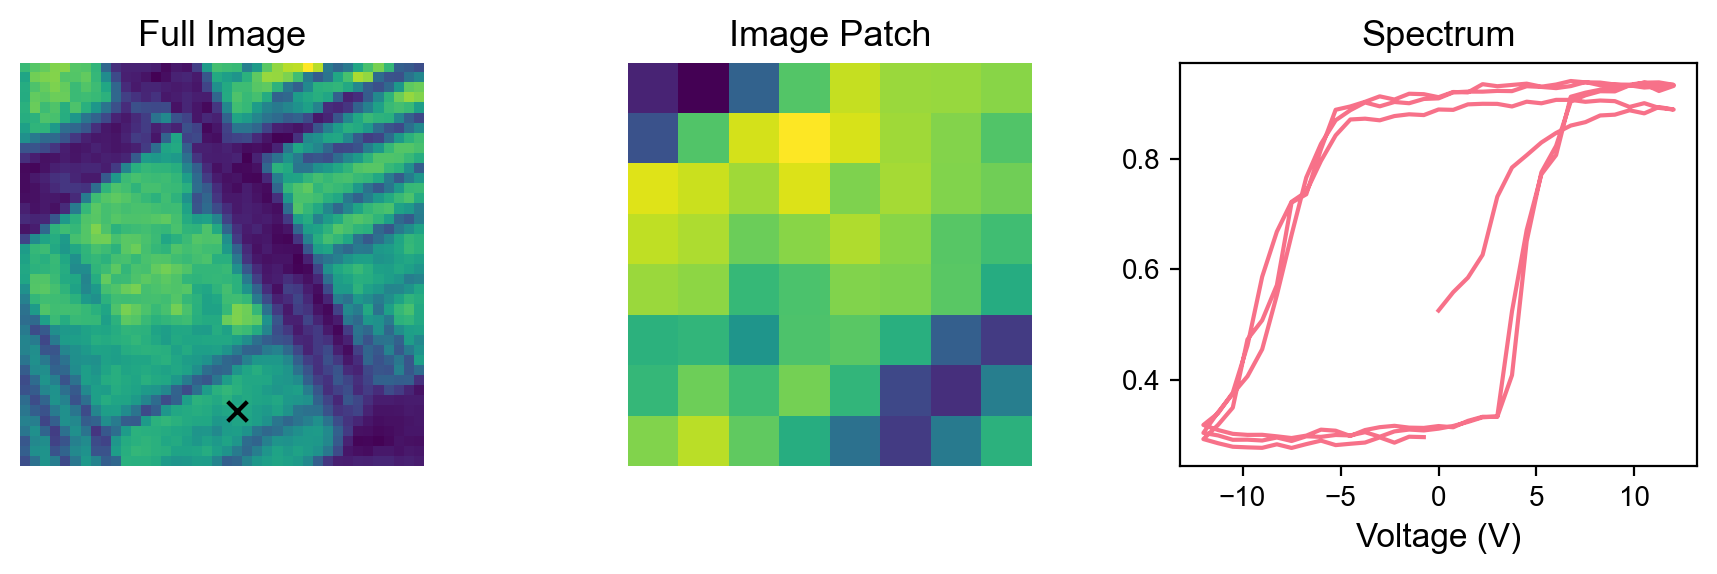

In [8]:
# Visualize example patch
k_example = 50
f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(9, 3), dpi=200)
ax1.imshow(img, origin='lower')
ax1.scatter(coords[k_example, 1], coords[k_example, 0], marker='x', s=50, c='k')
ax1.axis("off")
ax1.set_title('Full Image')

ax2.imshow(features_all[k_example], origin='lower')
ax2.axis("off")
ax2.set_title('Image Patch')

ax3.plot(v_step, spectra[coords[k_example, 0], coords[k_example, 1]])
ax3.set_title('Spectrum')
ax3.set_xlabel('Voltage (V)')
plt.tight_layout()
plt.show()

### Compute Loop Areas

-- The loop area for each spectrum gives us the "ground truth" quality at each location

-- In practice, we will not use these directly, it just gives us a ground truth to understand the performance of DeepKernelPairwiseGP

-- We will only use pairwise comparisons: "Is loop 0 better than 1?"

(np.float64(-0.5), np.float64(32.5), np.float64(-0.5), np.float64(32.5))

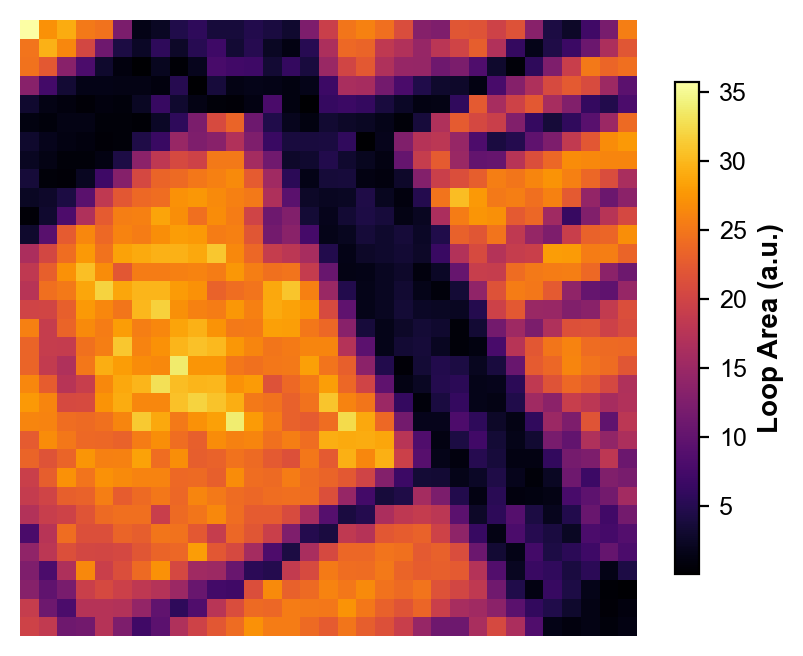

In [9]:
psize = 33
# Normalize and compute loop areas
features = norm_(features_all)
targets = norm_(targets)

loop_areas_all = []
for i, t in enumerate(targets):
    looparea = loop_area(t, 3)
    loop_areas_all.append(np.array([looparea]))

loop_areas_all = np.concatenate(loop_areas_all)

# Visualize loop areas
plt.figure(figsize=(5, 4), dpi =200)
a = plt.imshow(loop_areas_all.reshape(psize , psize), cmap = 'inferno', origin = 'lower')
# plt.colorbar(a, label='Loop Area (a.u.)', shrink=0.8, fontweight='bold', fontsize=10)
cbar1 = plt.colorbar(a, shrink=0.8)
cbar1.set_label('Loop Area (a.u.)', fontweight='bold', fontsize=10)
cbar1.ax.tick_params(labelsize=9)
plt.axis('off')
# plt.title('Loop Area',fontweight='bold', fontsize=12,)

In [10]:
# Prepare data arrays
n, d1, d2 = features_all.shape
X = features_all.reshape(n, d1*d2)  # Flattened patches for DKL
y_area = norm_(loop_areas_all)  # Scalarized values

print(f"X_train shape: {X.shape}")
print(f"y shape: {y_area.shape}")
print(f"Coords shape: {coords.shape}")

X_train shape: (1089, 64)
y shape: (1089,)
Coords shape: (1089, 2)


In [ ]:
def correlation_analysis(path):
    result = np.load(path)
    mean = result['mean']
    rank_correlation, pvalue = spearmanr(y_area, mean)
    ssim_value = ssim(y_area, norm_(mean[:,0]), data_range=1)
    return [rank_correlation, pvalue, ssim_value]

In [ ]:
# Load results of DKLPairWiseGP where no confidence weight and no tie are used
ncnt_fc = []
ncnt_fcbn = []
ncnt_resnet = []
ncnt_attention = []
for rs in range (5):
    for step in range (50):
        r = correlation_analysis(path = f'Extractors/noconfidence_notie/fc_rs_{rs}_npp_1_step_{step}.npz')
        ncnt_fc.append(r)
        r = correlation_analysis(path = f'Extractors/noconfidence_notie/fcbn_rs_{rs}_npp_1_step_{step}.npz')
        ncnt_fcbn.append(r)
        r = correlation_analysis(path = f'Extractors/noconfidence_notie/resnet_rs_{rs}_npp_1_step_{step}.npz')
        ncnt_resnet.append(r)
        r = correlation_analysis(path = f'Extractors/noconfidence_notie/attention_rs_{rs}_npp_1_step_{step}.npz')
        ncnt_attention.append(r)

ncnt_fc = np.array(ncnt_fc).reshape(5, 50, 3)
ncnt_fcbn = np.array(ncnt_fcbn).reshape(5, 50, 3)
ncnt_resnet = np.array(ncnt_resnet).reshape(5, 50, 3)
ncnt_attention = np.array(ncnt_attention).reshape(5, 50, 3)
ncnt_fc.shape, ncnt_fcbn.shape, ncnt_resnet.shape, ncnt_attention.shape

In [ ]:
# Load results of DKLPairWiseGP where confidence weight is used but no tie is used
cnt_fc = []
cnt_fcbn = []
cnt_resnet = []
cnt_attention = []
for rs in range (5):
    for step in range (50):
        r = correlation_analysis(path = f'Extractors/confidence_notie/fc_rs_{rs}_npp_1_step_{step}.npz')
        cnt_fc.append(r)
        r = correlation_analysis(path = f'Extractors/confidence_notie/fcbn_rs_{rs}_npp_1_step_{step}.npz')
        cnt_fcbn.append(r)
        r = correlation_analysis(path = f'Extractors/confidence_notie/resnet_rs_{rs}_npp_1_step_{step}.npz')
        cnt_resnet.append(r)
        r = correlation_analysis(path = f'Extractors/confidence_notie/attention_rs_{rs}_npp_1_step_{step}.npz')
        cnt_attention.append(r)

cnt_fc = np.array(cnt_fc).reshape(5, 50, 3)
cnt_fcbn = np.array(cnt_fcbn).reshape(5, 50, 3)
cnt_resnet = np.array(cnt_resnet).reshape(5, 50, 3)
cnt_attention = np.array(cnt_attention).reshape(5, 50, 3)
cnt_fc.shape, cnt_fcbn.shape, cnt_resnet.shape, cnt_attention.shape

((5, 50, 3), (5, 50, 3), (5, 50, 3), (5, 50, 3))

In [17]:
# Load results of DKLPairWiseGP where no confidence weight is used but tie is used
nct_fc = []
nct_fcbn = []
nct_resnet = []
nct_attention = []
for rs in range (5):
    for step in range (50):
        r = correlation_analysis(path = f'Extractors/noconfidence_tie/fc_rs_{rs}_npp_1_step_{step}.npz')
        nct_fc.append(r)
        r = correlation_analysis(path = f'Extractors/noconfidence_tie/fcbn_rs_{rs}_npp_1_step_{step}.npz')
        nct_fcbn.append(r)
        r = correlation_analysis(path = f'Extractors/noconfidence_tie/resnet_rs_{rs}_npp_1_step_{step}.npz')
        nct_resnet.append(r)
        r = correlation_analysis(path = f'Extractors/noconfidence_tie/attention_rs_{rs}_npp_1_step_{step}.npz')
        nct_attention.append(r)

nct_fc = np.array(nct_fc).reshape(5, 50, 3)
nct_fcbn = np.array(nct_fcbn).reshape(5, 50, 3)
nct_resnet = np.array(nct_resnet).reshape(5, 50, 3)
nct_attention = np.array(nct_attention).reshape(5, 50, 3)
nct_fc.shape, nct_fcbn.shape, nct_resnet.shape, nct_attention.shape

((5, 50, 3), (5, 50, 3), (5, 50, 3), (5, 50, 3))

In [18]:
# Load results of DKLPairWiseGP where confidence weight and tie are used
ct_fc = []
ct_fcbn = []
ct_resnet = []
ct_attention = []
for rs in range (5):
    for step in range (50):
        r = correlation_analysis(path = f'Extractors/confidence_tie/fc_rs_{rs}_npp_1_step_{step}.npz')
        ct_fc.append(r)
        r = correlation_analysis(path = f'Extractors/confidence_tie/fcbn_rs_{rs}_npp_1_step_{step}.npz')
        ct_fcbn.append(r)
        r = correlation_analysis(path = f'Extractors/confidence_tie/resnet_rs_{rs}_npp_1_step_{step}.npz')
        ct_resnet.append(r)
        r = correlation_analysis(path = f'Extractors/confidence_tie/attention_rs_{rs}_npp_1_step_{step}.npz')
        ct_attention.append(r)

ct_fc = np.array(ct_fc).reshape(5, 50, 3)
ct_fcbn = np.array(ct_fcbn).reshape(5, 50, 3)
ct_resnet = np.array(ct_resnet).reshape(5, 50, 3)
ct_attention = np.array(ct_attention).reshape(5, 50, 3)
ct_fc.shape, ct_fcbn.shape, ct_resnet.shape, ct_attention.shape

((5, 50, 3), (5, 50, 3), (5, 50, 3), (5, 50, 3))

In [19]:
# Calculate means and standard deviations
mean_ncnt_fc = ncnt_fc.mean(0)
std_ncnt_fc = ncnt_fc.std(0)

mean_ncnt_fcbn = ncnt_fcbn.mean(0)
std_ncnt_fcbn = ncnt_fcbn.std(0)

mean_ncnt_resnet = ncnt_resnet.mean(0)
std_ncnt_resnet = ncnt_resnet.std(0)

mean_ncnt_attention = ncnt_attention.mean(0)
std_ncnt_attention = ncnt_attention.std(0)

mean_nct_fc = nct_fc.mean(0)
std_nct_fc = nct_fc.std(0)

mean_nct_fcbn = nct_fcbn.mean(0)
std_nct_fcbn = nct_fcbn.std(0)

mean_nct_resnet = nct_resnet.mean(0)
std_nct_resnet = nct_resnet.std(0)

mean_nct_attention = nct_attention.mean(0)
std_nct_attention = nct_attention.std(0)

mean_cnt_fc = cnt_fc.mean(0)
std_cnt_fc = cnt_fc.std(0)

mean_cnt_fcbn = cnt_fcbn.mean(0)
std_cnt_fcbn = cnt_fcbn.std(0)

mean_cnt_resnet = cnt_resnet.mean(0)
std_cnt_resnet = cnt_resnet.std(0)

mean_cnt_attention = cnt_attention.mean(0)
std_cnt_attention = cnt_attention.std(0)

mean_ct_fc = ct_fc.mean(0)
std_ct_fc = ct_fc.std(0)

mean_ct_fcbn = ct_fcbn.mean(0)
std_ct_fcbn = ct_fcbn.std(0)

mean_ct_resnet = ct_resnet.mean(0)
std_ct_resnet = ct_resnet.std(0)

mean_ct_attention = ct_attention.mean(0)
std_ct_attention = ct_attention.std(0)

# Create x-axis
x = np.arange(50)

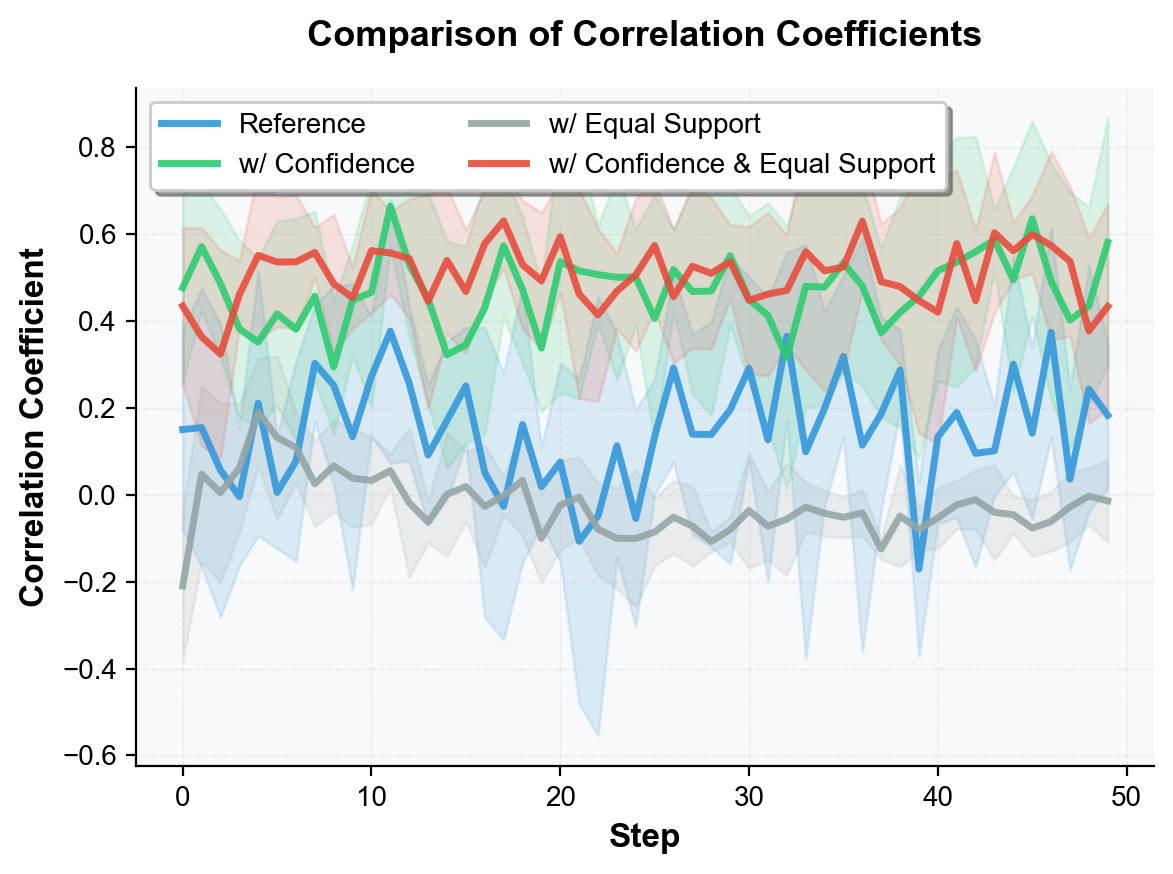

In [31]:
fig, ax = plt.subplots(figsize=(6, 4.5), dpi=200)

# Modern color palette
colors = ['#3498DB', '#2ECC71', '#95A5A6', '#E74C3C']
labels = ['Reference', 'w/ Confidence', 'w/ Equal Support', 'w/ Confidence & Equal Support']

k = 0
# Data pairs
data_pairs = [
    (mean_ncnt_fc[:,k], std_ncnt_fc[:,k]),
    (mean_nct_fc[:,k], std_nct_fc[:,k]),
    (mean_cnt_fc[:,k], std_cnt_fc[:,k]),
    (mean_ct_fc[:,k], std_ct_fc[:,k])
]

# Plot each line with shaded region
for i, (mean_data, std_data) in enumerate(data_pairs):
    # Main line (no markers)
    ax.plot(x, mean_data, color=colors[i], linewidth=2.5, label=labels[i], alpha=0.9)
    
    # Shaded standard deviation
    ax.fill_between(x, mean_data - std_data,  mean_data + std_data, color=colors[i], alpha=0.15)

# Styling
ax.set_xlabel('Step', fontweight='bold', fontsize=12)
ax.set_ylabel('Correlation Coefficient', fontweight='bold', fontsize=12)
ax.set_title('Comparison of Correlation Coefficients', fontweight='bold', fontsize=13, pad=15)

# Enhanced legend
ax.legend(loc='upper left', frameon=True, fancybox=True, shadow=True, fontsize=10,ncol=2)

# Grid
ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.5)
ax.set_facecolor('#F8F9FA')

# Remove top and right spines
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

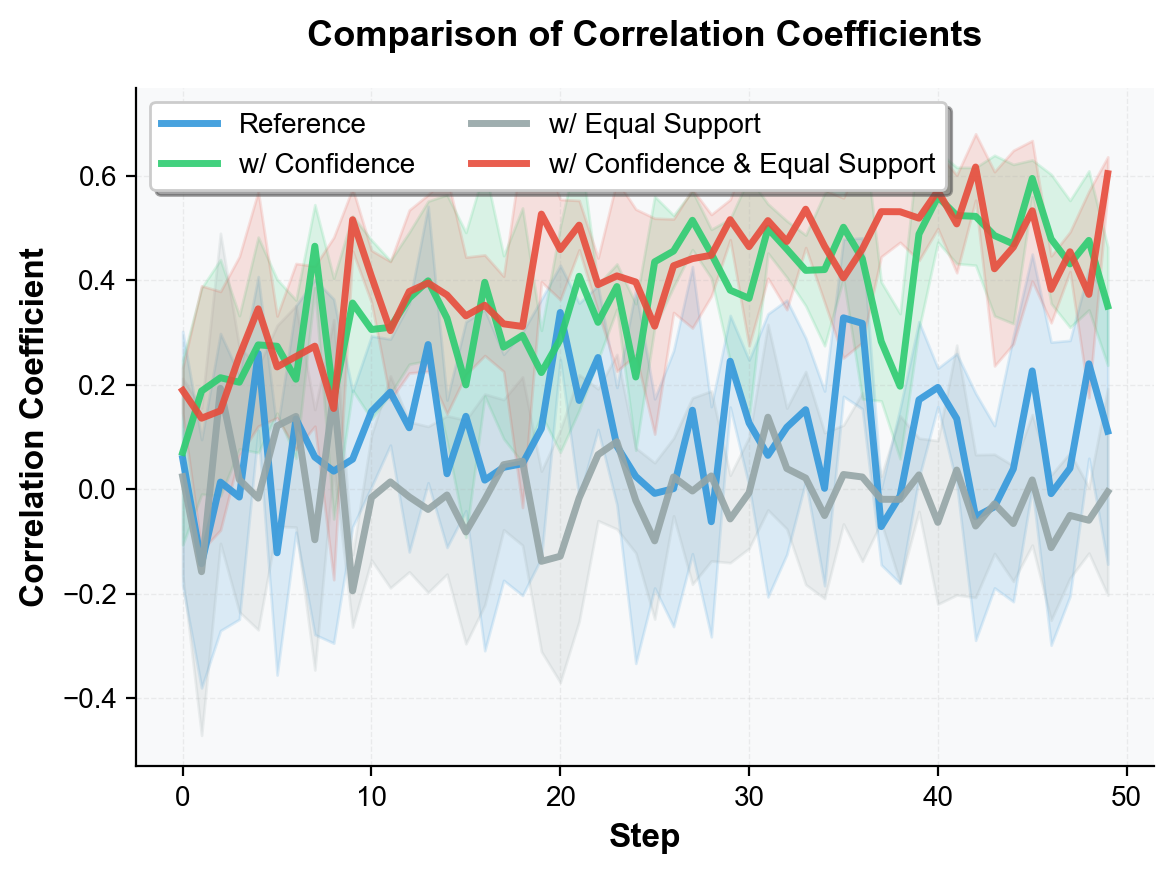

In [32]:
fig, ax = plt.subplots(figsize=(6, 4.5), dpi=200)

# Modern color palette
colors = ['#3498DB', '#2ECC71', '#95A5A6', '#E74C3C']
labels = ['Reference', 'w/ Confidence', 'w/ Equal Support', 'w/ Confidence & Equal Support']

# Data pairs
data_pairs = [
    (mean_ncnt_fcbn[:,k], std_ncnt_fcbn[:,k]),
    (mean_nct_fcbn[:,k], std_nct_fcbn[:,k]),
    (mean_cnt_fcbn[:,k], std_cnt_fcbn[:,k]),
    (mean_ct_fcbn[:,k], std_ct_fcbn[:,k])
]

# Plot each line with shaded region
for i, (mean_data, std_data) in enumerate(data_pairs):
    # Main line (no markers)
    ax.plot(x, mean_data, color=colors[i], linewidth=2.5, label=labels[i], alpha=0.9)
    
    # Shaded standard deviation
    ax.fill_between(x, mean_data - std_data,  mean_data + std_data, color=colors[i], alpha=0.15)

# Styling
ax.set_xlabel('Step', fontweight='bold', fontsize=12)
ax.set_ylabel('Correlation Coefficient', fontweight='bold', fontsize=12)
ax.set_title('Comparison of Correlation Coefficients', fontweight='bold', fontsize=13, pad=15)

# Enhanced legend
ax.legend(loc='upper left', frameon=True, fancybox=True, shadow=True, fontsize=10,ncol=2)

# Grid
ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.5)
ax.set_facecolor('#F8F9FA')

# Remove top and right spines
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

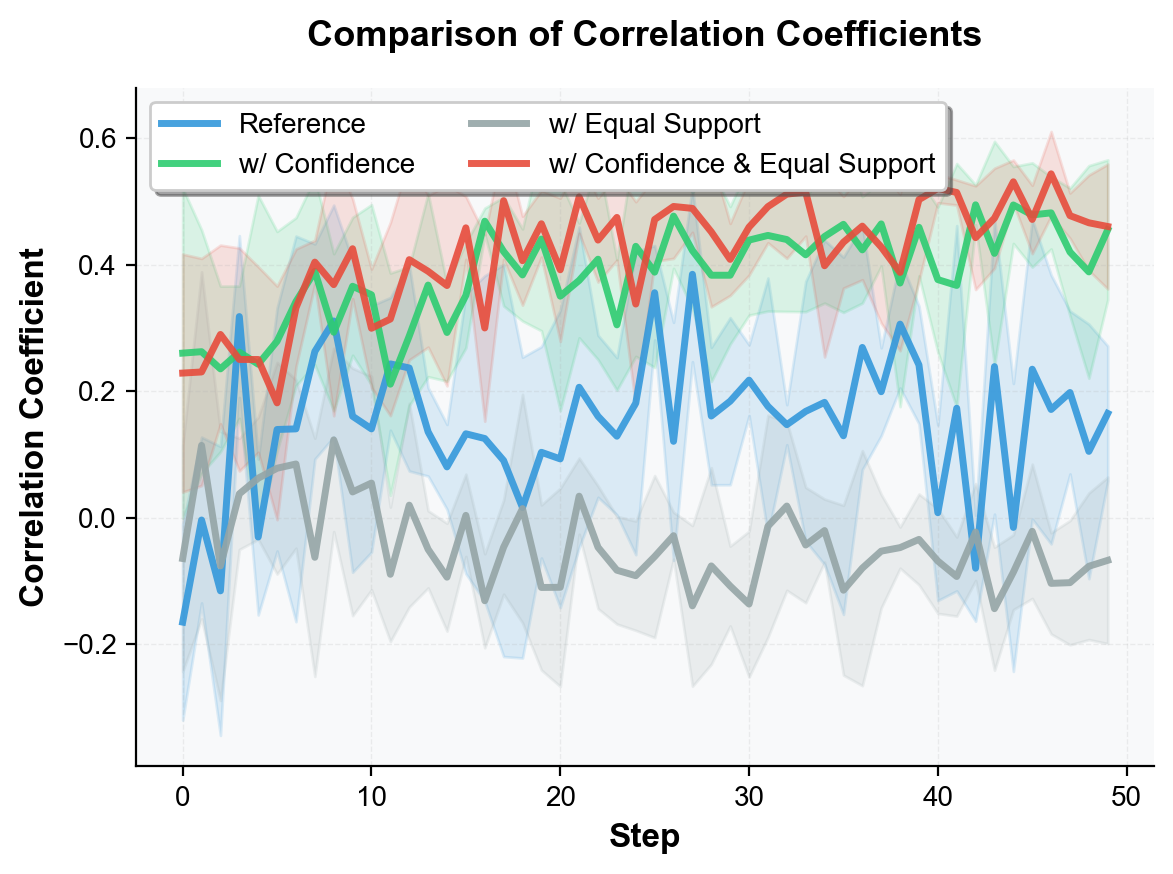

In [33]:
fig, ax = plt.subplots(figsize=(6, 4.5), dpi=200)

# Modern color palette
colors = ['#3498DB', '#2ECC71', '#95A5A6', '#E74C3C']
labels = ['Reference', 'w/ Confidence', 'w/ Equal Support', 'w/ Confidence & Equal Support']

# Data pairs
data_pairs = [
    (mean_ncnt_resnet[:,k], std_ncnt_resnet[:,k]),
    (mean_nct_resnet[:,k], std_nct_resnet[:,k]),
    (mean_cnt_resnet[:,k], std_cnt_resnet[:,k]),
    (mean_ct_resnet[:,k], std_ct_resnet[:,k])
]

# Plot each line with shaded region
for i, (mean_data, std_data) in enumerate(data_pairs):
    # Main line (no markers)
    ax.plot(x, mean_data, color=colors[i], linewidth=2.5, label=labels[i], alpha=0.9)
    
    # Shaded standard deviation
    ax.fill_between(x, mean_data - std_data,  mean_data + std_data, color=colors[i], alpha=0.15)

# Styling
ax.set_xlabel('Step', fontweight='bold', fontsize=12)
ax.set_ylabel('Correlation Coefficient', fontweight='bold', fontsize=12)
ax.set_title('Comparison of Correlation Coefficients', fontweight='bold', fontsize=13, pad=15)

# Enhanced legend
ax.legend(loc='upper left', frameon=True, fancybox=True, shadow=True, fontsize=10,ncol=2)

# Grid
ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.5)
ax.set_facecolor('#F8F9FA')

# Remove top and right spines
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

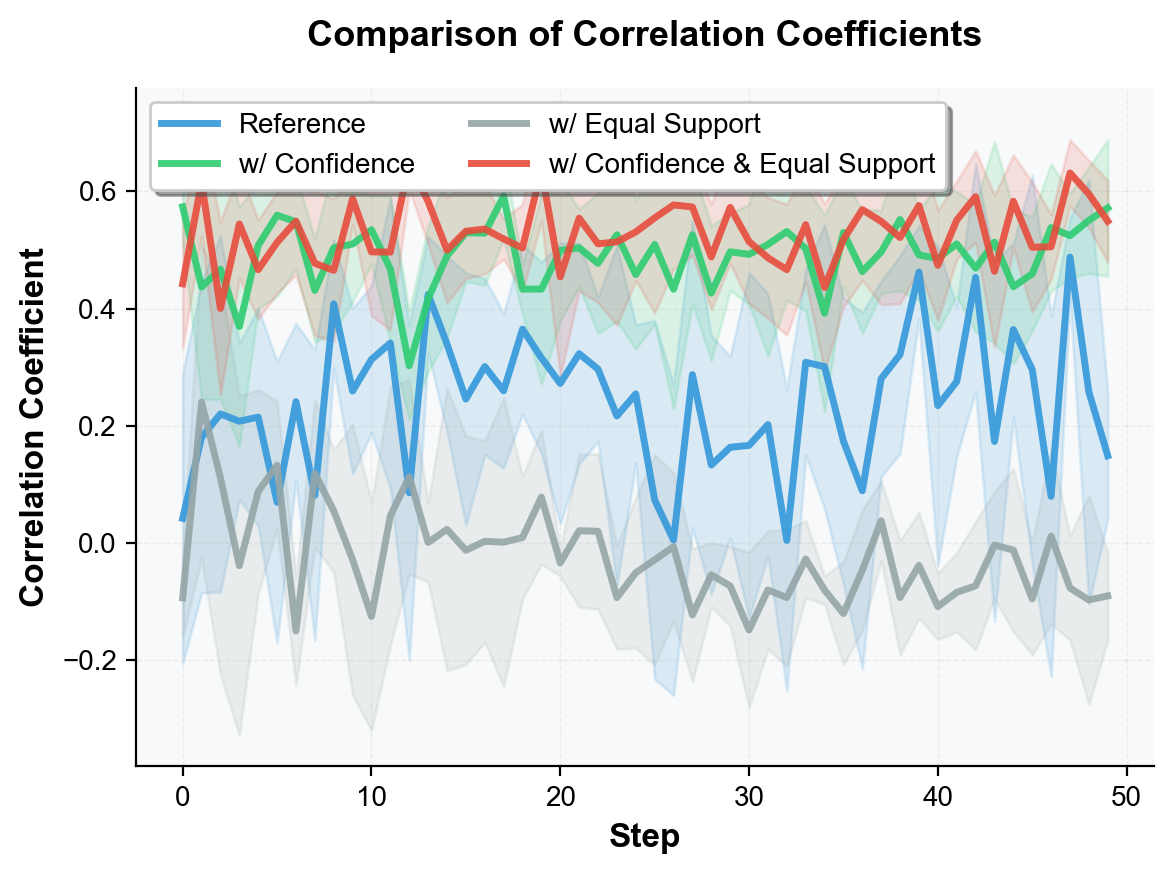

In [34]:
fig, ax = plt.subplots(figsize=(6, 4.5), dpi=200)

# Modern color palette
colors = ['#3498DB', '#2ECC71', '#95A5A6', '#E74C3C']
labels = ['Reference', 'w/ Confidence', 'w/ Equal Support', 'w/ Confidence & Equal Support']

# Data pairs
data_pairs = [
    (mean_ncnt_attention[:,k], std_ncnt_attention[:,k]),
    (mean_nct_attention[:,k], std_nct_attention[:,k]),
    (mean_cnt_attention[:,k], std_cnt_attention[:,k]),
    (mean_ct_attention[:,k], std_ct_attention[:,k])
]

# Plot each line with shaded region
for i, (mean_data, std_data) in enumerate(data_pairs):
    # Main line (no markers)
    ax.plot(x, mean_data, color=colors[i], linewidth=2.5, label=labels[i], alpha=0.9)
    
    # Shaded standard deviation
    ax.fill_between(x, mean_data - std_data,  mean_data + std_data, color=colors[i], alpha=0.15)

# Styling
ax.set_xlabel('Step', fontweight='bold', fontsize=12)
ax.set_ylabel('Correlation Coefficient', fontweight='bold', fontsize=12)
ax.set_title('Comparison of Correlation Coefficients', fontweight='bold', fontsize=13, pad=15)

# Enhanced legend
ax.legend(loc='upper left', frameon=True, fancybox=True, shadow=True, fontsize=10,ncol=2)

# Grid
ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.5)
ax.set_facecolor('#F8F9FA')

# Remove top and right spines
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

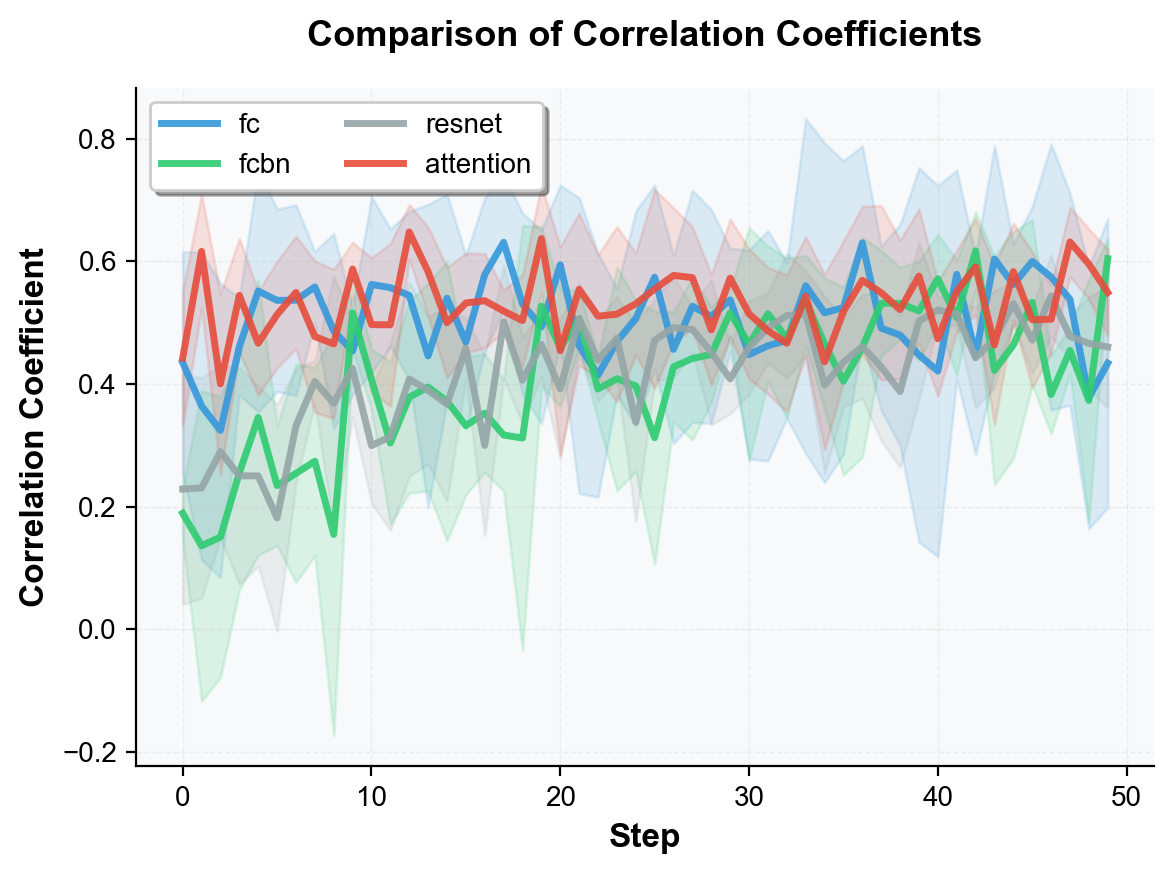

In [37]:
fig, ax = plt.subplots(figsize=(6, 4.5), dpi=200)

# Modern color palette
colors = ['#3498DB', '#2ECC71', '#95A5A6', '#E74C3C']
labels = ['fc', 'fcbn', 'resnet', 'attention']

# Data pairs
data_pairs = [
    (mean_ct_fc[:,k], std_ct_fc[:,k]),
    (mean_ct_fcbn[:,k], std_ct_fcbn[:,k]),
    (mean_ct_resnet[:,k], std_ct_resnet[:,k]),
    (mean_ct_attention[:,k], std_ct_attention[:,k])
]

# Plot each line with shaded region
for i, (mean_data, std_data) in enumerate(data_pairs):
    # Main line (no markers)
    ax.plot(x, mean_data, color=colors[i], linewidth=2.5, label=labels[i], alpha=0.9)
    
    # Shaded standard deviation
    ax.fill_between(x, mean_data - std_data,  mean_data + std_data, color=colors[i], alpha=0.15)

# Styling
ax.set_xlabel('Step', fontweight='bold', fontsize=12)
ax.set_ylabel('Correlation Coefficient', fontweight='bold', fontsize=12)
ax.set_title('Comparison of Correlation Coefficients', fontweight='bold', fontsize=13, pad=15)

# Enhanced legend
ax.legend(loc='upper left', frameon=True, fancybox=True, shadow=True, fontsize=10,ncol=2)

# Grid
ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.5)
ax.set_facecolor('#F8F9FA')

# Remove top and right spines
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

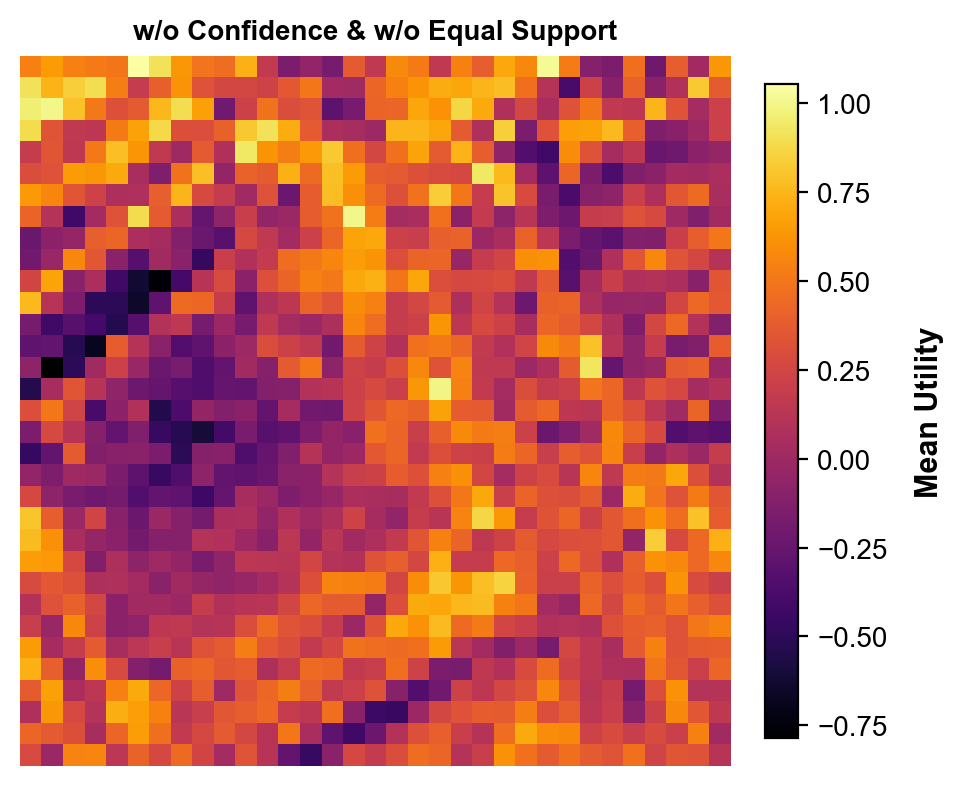

In [19]:
result = np.load ('StatisticAnalysis/no_confidence_no_tie/rs_0_npp_1_step_49.npz')
mean = result['mean']

fig, ax = plt.subplots(figsize=(5, 5), dpi=200)
# Enhanced imshow with better colormap and interpolation
im = ax.imshow(mean.reshape((psize, psize)), 
               origin='lower', 
               cmap='inferno',  # Modern colormap (try 'plasma', 'inferno', 'magma', 'cividis')
               aspect='equal')

# Add colorbar with label
cbar = plt.colorbar(im, ax=ax, shrink=0.7, pad=0.04)
cbar.set_label('Mean Utility', labelpad=10, fontweight='bold', fontsize=11)
cbar.ax.tick_params(labelsize=10)

# Add title
ax.set_title('w/o Confidence & w/o Equal Support', fontweight='bold', fontsize=10)

ax.axis('off')

plt.tight_layout()
plt.show()

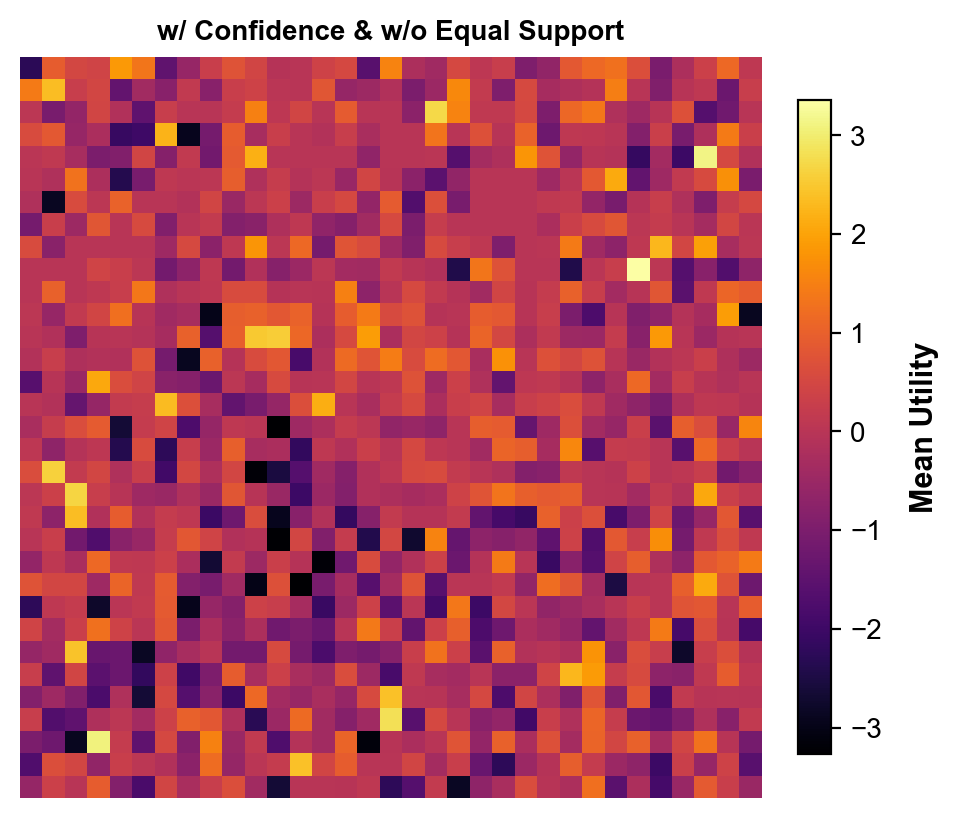

In [20]:
result = np.load ('StatisticAnalysis/confidence_notie/rs_0_npp_1_step_49.npz')
mean = result['mean']

fig, ax = plt.subplots(figsize=(5, 5), dpi=200)
# Enhanced imshow with better colormap and interpolation
im = ax.imshow(mean.reshape((psize, psize)), 
               origin='lower', 
               cmap='inferno',  # Modern colormap (try 'plasma', 'inferno', 'magma', 'cividis')
               aspect='equal')

# Add colorbar with label
cbar = plt.colorbar(im, ax=ax, shrink=0.7, pad=0.04)
cbar.set_label('Mean Utility', labelpad=10, fontweight='bold', fontsize=11)
cbar.ax.tick_params(labelsize=10)

# Add title
ax.set_title('w/ Confidence & w/o Equal Support', fontweight='bold', fontsize=10)

ax.axis('off')

plt.tight_layout()
plt.show()

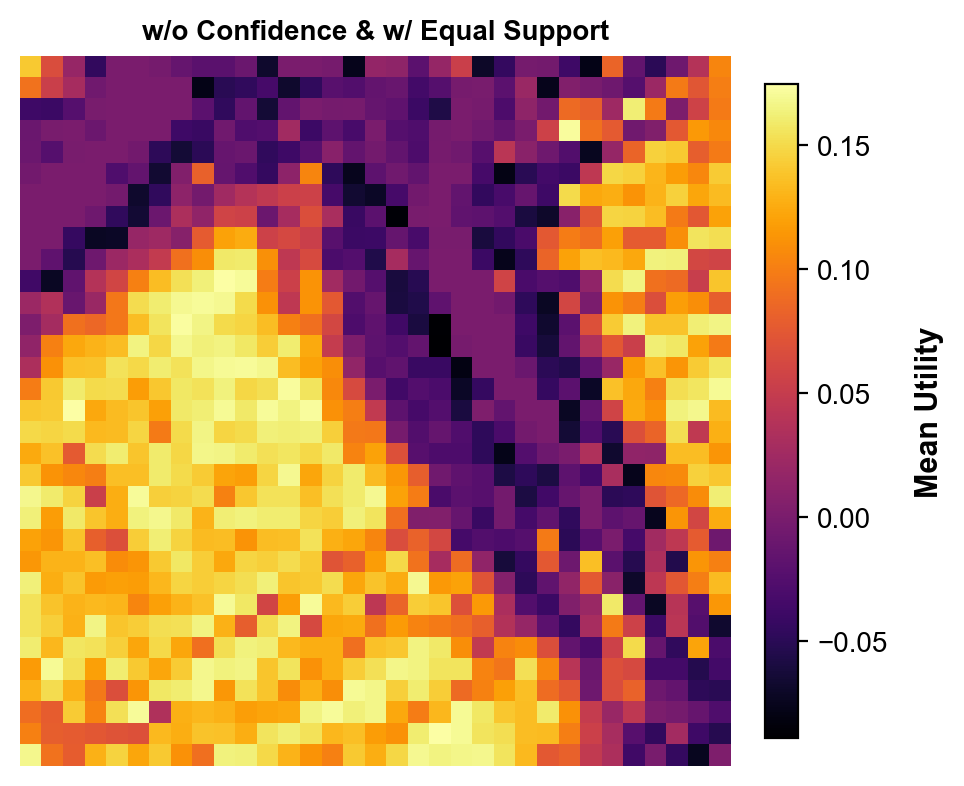

In [21]:
result = np.load ('StatisticAnalysis/no_confidence_tie/rs_0_npp_1_step_49.npz')
mean = result['mean']

fig, ax = plt.subplots(figsize=(5, 5), dpi=200)
# Enhanced imshow with better colormap and interpolation
im = ax.imshow(mean.reshape((psize, psize)), 
               origin='lower', 
               cmap='inferno',  # Modern colormap (try 'plasma', 'inferno', 'magma', 'cividis')
               aspect='equal')

# Add colorbar with label
cbar = plt.colorbar(im, ax=ax, shrink=0.7, pad=0.04)
cbar.set_label('Mean Utility', labelpad=10, fontweight='bold', fontsize=11)
cbar.ax.tick_params(labelsize=10)

# Add title
ax.set_title('w/o Confidence & w/ Equal Support', fontweight='bold', fontsize=10)

ax.axis('off')

plt.tight_layout()
plt.show()

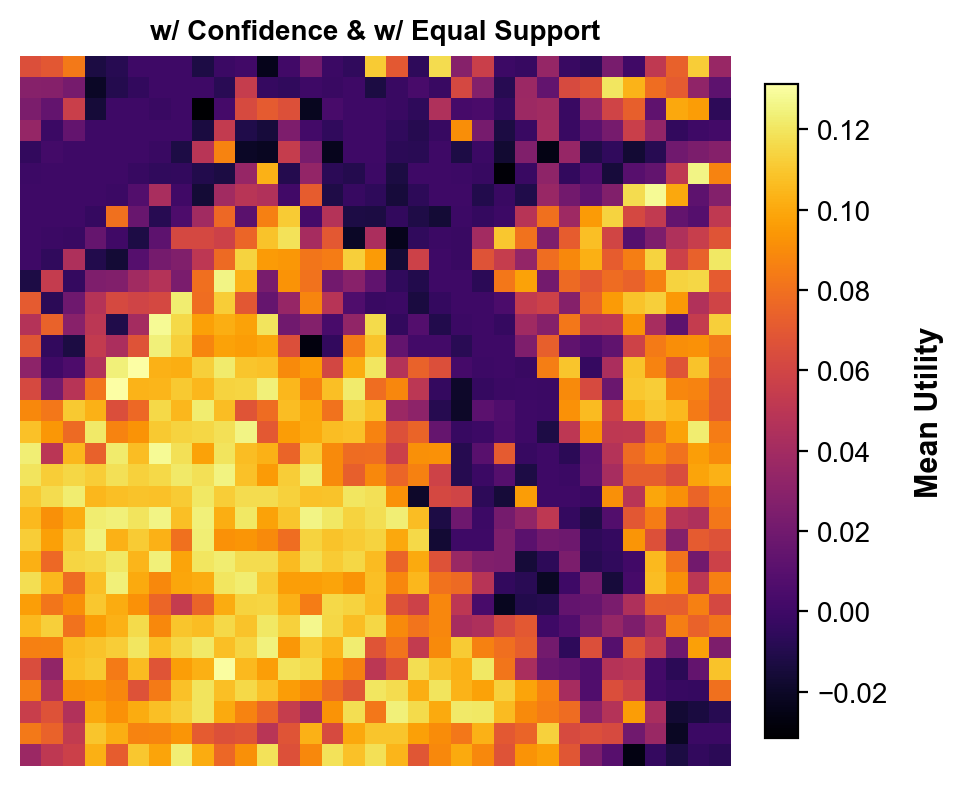

In [22]:
result = np.load ('StatisticAnalysis/confidence_tie/rs_0_npp_1_step_49.npz')
mean = result['mean']

fig, ax = plt.subplots(figsize=(5, 5), dpi=200)
# Enhanced imshow with better colormap and interpolation
im = ax.imshow(mean.reshape((psize, psize)), 
               origin='lower', 
               cmap='inferno',  # Modern colormap (try 'plasma', 'inferno', 'magma', 'cividis')
               aspect='equal')

# Add colorbar with label
cbar = plt.colorbar(im, ax=ax, shrink=0.7, pad=0.04)
cbar.set_label('Mean Utility', labelpad=10, fontweight='bold', fontsize=11)
cbar.ax.tick_params(labelsize=10)

# Add title
ax.set_title('w/ Confidence & w/ Equal Support', fontweight='bold', fontsize=10)

ax.axis('off')

plt.tight_layout()
plt.show()

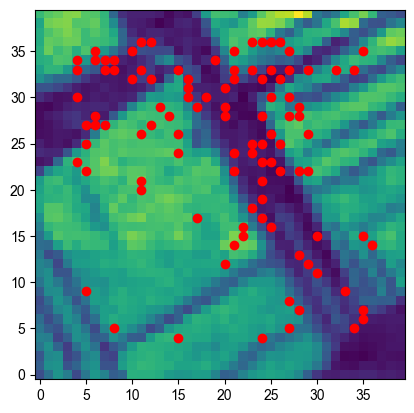

In [23]:
result = np.load ('StatisticAnalysis/no_confidence_no_tie/rs_9_npp_1_step_49.npz')
train_indices = result['train_indices']
train_coords = coords[train_indices]
plt.imshow(img, origin = "lower")
plt.scatter(train_coords[:,1], train_coords[:,0], c= 'r')

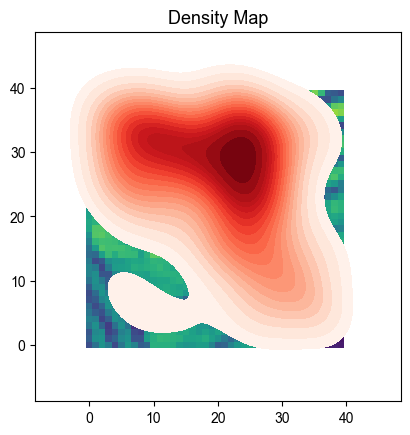

In [24]:
plt.imshow(img, origin = "lower")
sns.kdeplot(x=train_coords[:,1], y=train_coords[:,0], cmap='Reds', fill=True, levels=20)
plt.title('Density Map')
plt.show()

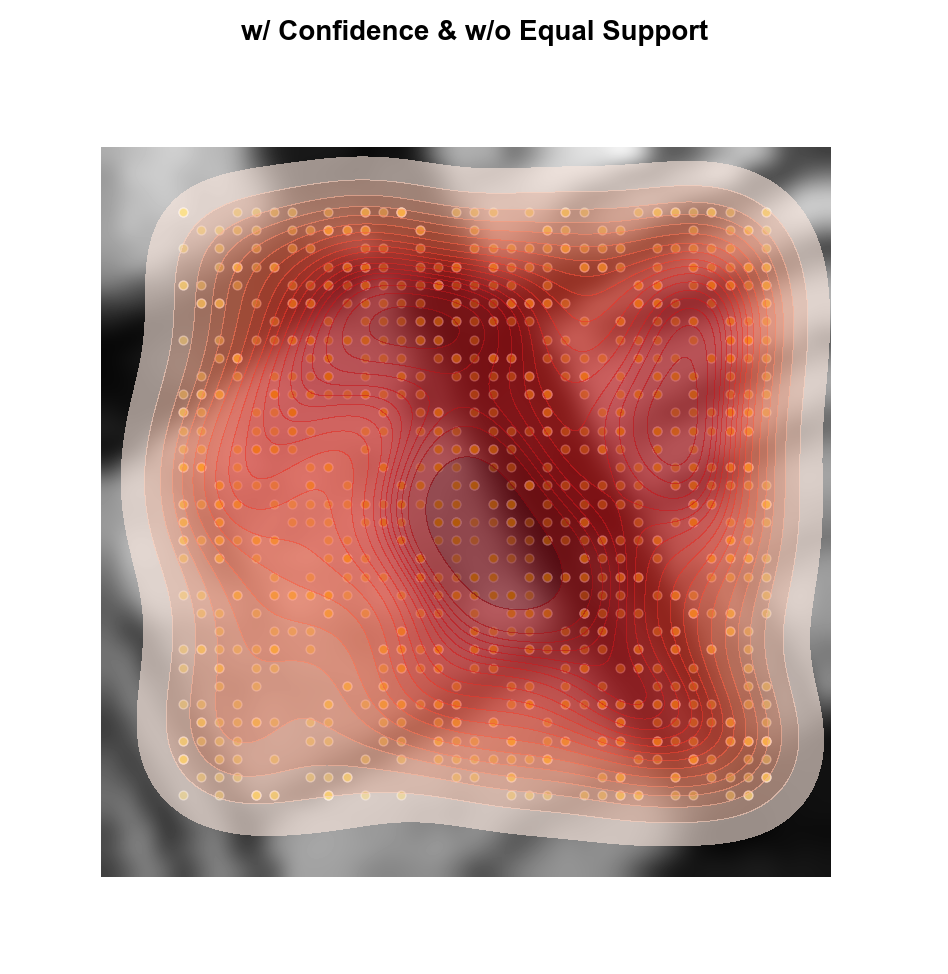

In [25]:
all_train_indices = []
for i in range (10):
    result = np.load (f'StatisticAnalysis/confidence_notie/rs_{i}_npp_1_step_49.npz')
    train_indices = result['train_indices']
    if i == 0:
        all_train_indices = train_indices
    else:
        all_train_indices = np.append(all_train_indices, train_indices)

train_coords = coords[all_train_indices]

fig, ax = plt.subplots(figsize=(5, 5), dpi=200)

ax.imshow(img, origin="lower", cmap='gray', interpolation='bicubic')

# Add scatter points with complementary color and high transparency
ax.scatter(train_coords[:,1], train_coords[:,0], 
           color='#FFD700',  # Gold color (contrasts well with red)
           s=10,  # Smaller points
           alpha=0.5,  # Very transparent - won't block density
           edgecolors='white',  # White outline for visibility
           linewidths=0.5,  # Thin outline
           marker='o',
           label='Training Points')


# KDE density plot
sns.kdeplot(x=train_coords[:,1], y=train_coords[:,0], 
            cmap='Reds',  # or try 'YlOrRd', 'hot', 'RdYlBu_r'
            fill=True, 
            levels=20,  # Cleaner contours
            alpha=0.6, 
            thresh=0.05,  # Remove noise
            ax=ax)

ax.set_title('w/ Confidence & w/o Equal Support', 
             fontweight='bold', fontsize=10, pad=5, color='black')
# ax.legend(loc='upper right', frameon=True, fancybox=True, 
#           shadow=True, fontsize=11, facecolor='black', 
#           edgecolor='white', framealpha=0.8, labelcolor='white')
ax.axis('off')

plt.tight_layout()
plt.show()


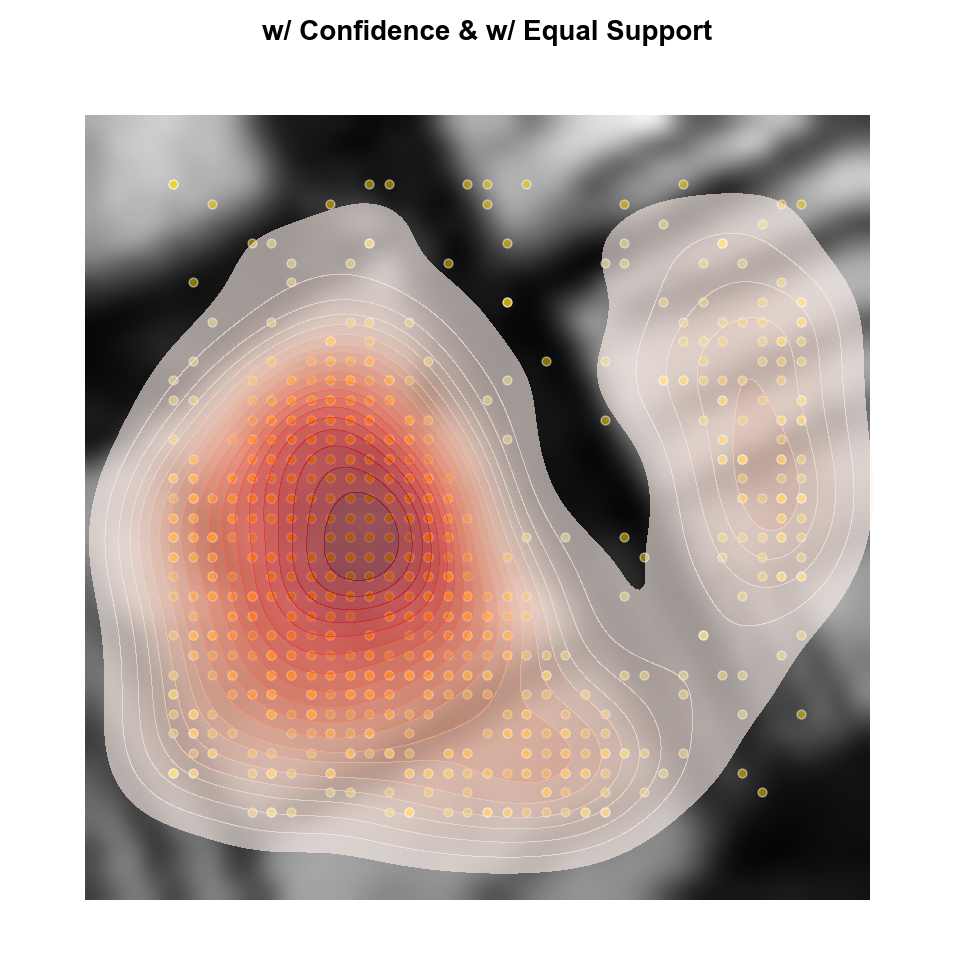

In [26]:
all_train_indices = []
for i in range (10):
    result = np.load (f'StatisticAnalysis/confidence_tie/rs_{i}_npp_1_step_49.npz')
    train_indices = result['train_indices']
    if i == 0:
        all_train_indices = train_indices
    else:
        all_train_indices = np.append(all_train_indices, train_indices)

train_coords = coords[all_train_indices]


fig, ax = plt.subplots(figsize=(5, 5), dpi=200)

ax.imshow(img, origin="lower", cmap='gray', interpolation='bicubic')

# Add scatter points with complementary color and high transparency
ax.scatter(train_coords[:,1], train_coords[:,0], 
           color='#FFD700',  # Gold color (contrasts well with red)
           s=10,  # Smaller points
           alpha=0.5,  # Very transparent - won't block density
           edgecolors='white',  # White outline for visibility
           linewidths=0.5,  # Thin outline
           marker='o',
           label='Training Points')


# KDE density plot
sns.kdeplot(x=train_coords[:,1], y=train_coords[:,0], 
            cmap='Reds',  # or try 'YlOrRd', 'hot', 'RdYlBu_r'
            fill=True, 
            levels=20,  # Cleaner contours
            alpha=0.6, 
            thresh=0.05,  # Remove noise
            ax=ax)

ax.set_title('w/ Confidence & w/ Equal Support', 
             fontweight='bold', fontsize=10, pad=5, color='black')
# ax.legend(loc='upper right', frameon=True, fancybox=True, 
#           shadow=True, fontsize=11, facecolor='black', 
#           edgecolor='white', framealpha=0.8, labelcolor='white')
ax.axis('off')

plt.tight_layout()
plt.show()

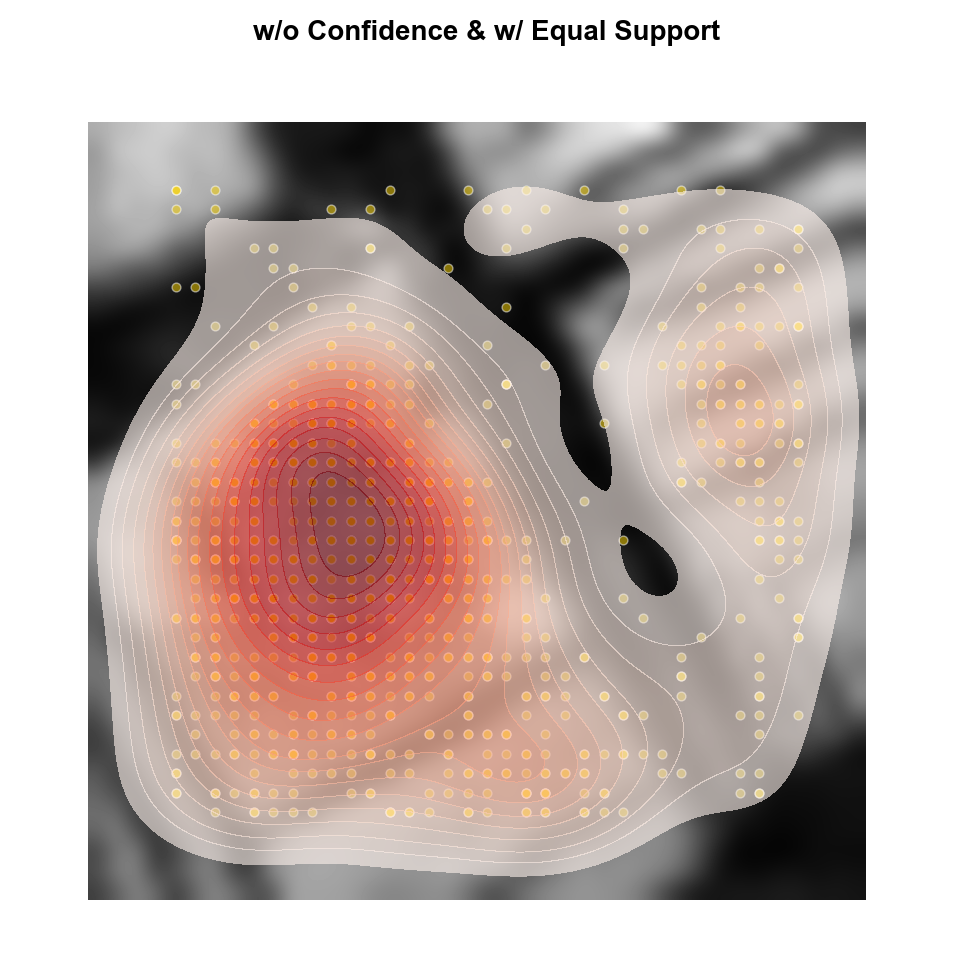

In [27]:
all_train_indices = []
for i in range (10):
    result = np.load (f'StatisticAnalysis/no_confidence_tie/rs_{i}_npp_1_step_49.npz')
    train_indices = result['train_indices']
    if i == 0:
        all_train_indices = train_indices
    else:
        all_train_indices = np.append(all_train_indices, train_indices)

train_coords = coords[all_train_indices]

fig, ax = plt.subplots(figsize=(5, 5), dpi=200)

ax.imshow(img, origin="lower", cmap='gray', interpolation='bicubic')

# Add scatter points with complementary color and high transparency
ax.scatter(train_coords[:,1], train_coords[:,0], 
           color='#FFD700',  # Gold color (contrasts well with red)
           s=10,  # Smaller points
           alpha=0.5,  # Very transparent - won't block density
           edgecolors='white',  # White outline for visibility
           linewidths=0.5,  # Thin outline
           marker='o',
           label='Training Points')


# KDE density plot
sns.kdeplot(x=train_coords[:,1], y=train_coords[:,0], 
            cmap='Reds',  # or try 'YlOrRd', 'hot', 'RdYlBu_r'
            fill=True, 
            levels=20,  # Cleaner contours
            alpha=0.6, 
            thresh=0.05,  # Remove noise
            ax=ax)

ax.set_title('w/o Confidence & w/ Equal Support', 
             fontweight='bold', fontsize=10, pad=5, color='black')
# ax.legend(loc='upper right', frameon=True, fancybox=True, 
#           shadow=True, fontsize=11, facecolor='black', 
#           edgecolor='white', framealpha=0.8, labelcolor='white')
ax.axis('off')

plt.tight_layout()
plt.show()

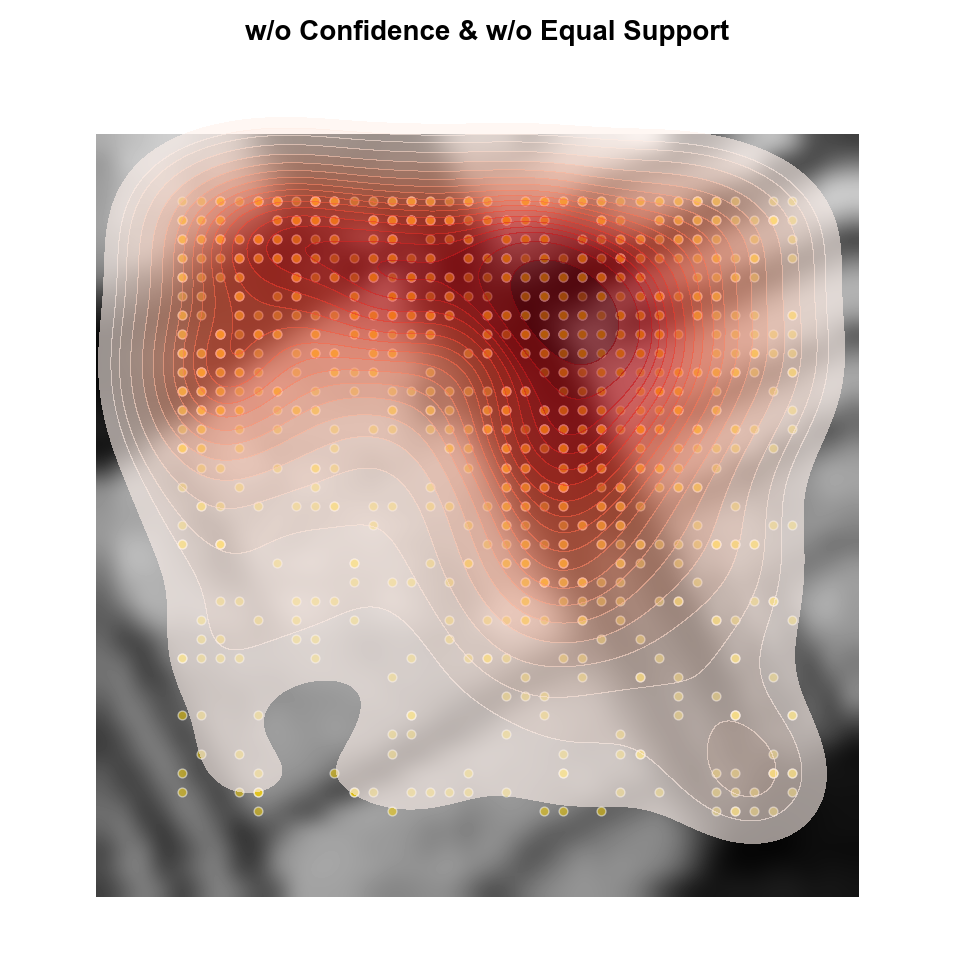

In [28]:
all_train_indices = []
for i in range (10):
    result = np.load (f'StatisticAnalysis/no_confidence_no_tie/rs_{i}_npp_1_step_49.npz')
    train_indices = result['train_indices']
    if i == 0:
        all_train_indices = train_indices
    else:
        all_train_indices = np.append(all_train_indices, train_indices)

train_coords = coords[all_train_indices]

fig, ax = plt.subplots(figsize=(5, 5), dpi=200)

ax.imshow(img, origin="lower", cmap='gray', interpolation='bicubic')

# Add scatter points with complementary color and high transparency
ax.scatter(train_coords[:,1], train_coords[:,0], 
           color='#FFD700',  # Gold color (contrasts well with red)
           s=10,  # Smaller points
           alpha=0.5,  # Very transparent - won't block density
           edgecolors='white',  # White outline for visibility
           linewidths=0.5,  # Thin outline
           marker='o',
           label='Training Points')


# KDE density plot
sns.kdeplot(x=train_coords[:,1], y=train_coords[:,0], 
            cmap='Reds',  # or try 'YlOrRd', 'hot', 'RdYlBu_r'
            fill=True, 
            levels=20,  # Cleaner contours
            alpha=0.6, 
            thresh=0.05,  # Remove noise
            ax=ax)

ax.set_title('w/o Confidence & w/o Equal Support', 
             fontweight='bold', fontsize=10, pad=5, color='black')
# ax.legend(loc='upper right', frameon=True, fancybox=True, 
#           shadow=True, fontsize=11, facecolor='black', 
#           edgecolor='white', framealpha=0.8, labelcolor='white')
ax.axis('off')

plt.tight_layout()
plt.show()

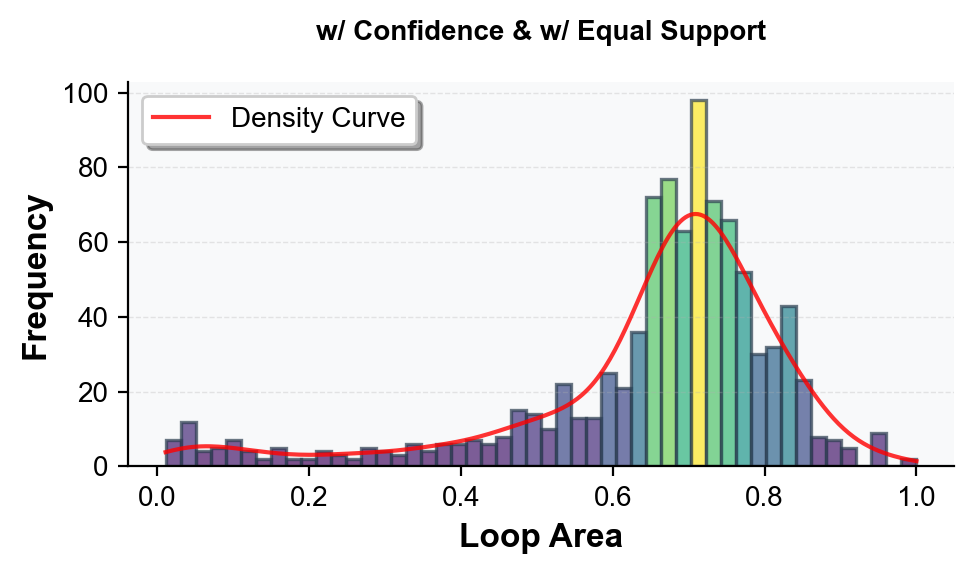

In [29]:
all_train_indices = []
for i in range (10):
    result = np.load (f'StatisticAnalysis/confidence_tie/rs_{i}_npp_1_step_49.npz')
    train_indices = result['train_indices']
    if i == 0:
        all_train_indices = train_indices
    else:
        all_train_indices = np.append(all_train_indices, train_indices)

train_loopareas = y_area[all_train_indices]

fig, ax = plt.subplots(figsize=(5, 3), dpi=200)

# Create histogram with improved styling
n, bins, patches = ax.hist(train_loopareas, bins=50, 
                           color='#3498db', 
                           alpha=0.7, 
                           edgecolor='#2c3e50', 
                           linewidth=1.2)

# Add a gradient effect to bars (optional but beautiful!)
# Color bars based on height
cm = plt.cm.viridis
norm = plt.Normalize(vmin=n.min(), vmax=n.max())
for i, patch in enumerate(patches):
    patch.set_facecolor(cm(norm(n[i])))

# Add a KDE curve overlay for smoothness
from scipy.stats import gaussian_kde
kde = gaussian_kde(train_loopareas)
x_range = np.linspace(train_loopareas.min(), train_loopareas.max(), 300)
kde_values = kde(x_range)

# Scale KDE to match histogram
kde_scaled = kde_values * len(train_loopareas) * (bins[1] - bins[0])
ax.plot(x_range, kde_scaled, 'r-', linewidth=1.5, 
        label='Density Curve', alpha=0.8)
ax.set_title('w/ Confidence & w/ Equal Support', 
             fontweight='bold', fontsize=10, pad=15)
# Styling
ax.set_xlabel('Loop Area', fontweight='bold', fontsize=12)
ax.set_ylabel('Frequency', fontweight='bold', fontsize=12)
ax.legend(fontsize=10, frameon=True, fancybox=True, shadow=True, loc='best')
ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_facecolor('#F8F9FA')

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

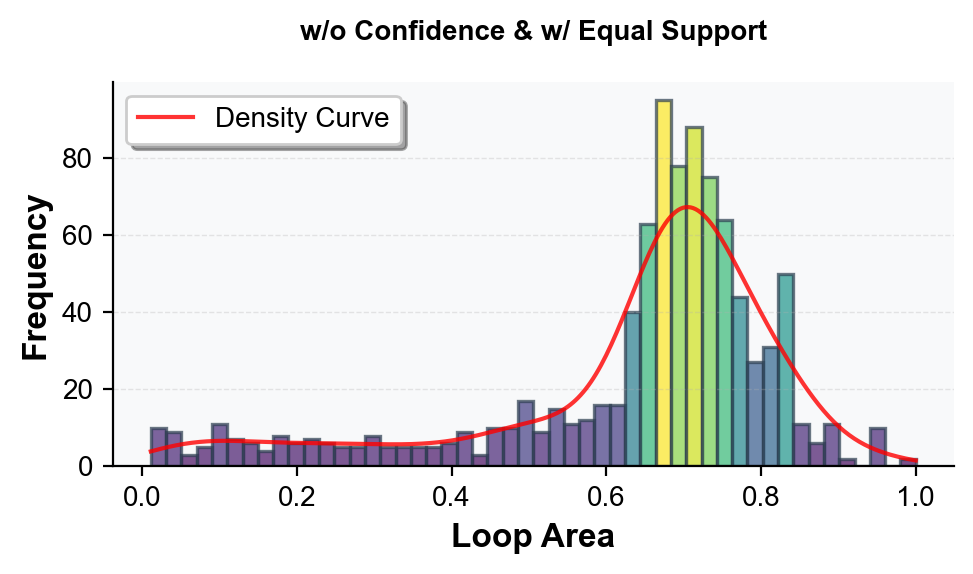

In [30]:
all_train_indices = []
for i in range (10):
    result = np.load (f'StatisticAnalysis/no_confidence_tie/rs_{i}_npp_1_step_49.npz')
    train_indices = result['train_indices']
    if i == 0:
        all_train_indices = train_indices
    else:
        all_train_indices = np.append(all_train_indices, train_indices)

train_loopareas = y_area[all_train_indices]

fig, ax = plt.subplots(figsize=(5, 3), dpi=200)

# Create histogram with improved styling
n, bins, patches = ax.hist(train_loopareas, bins=50, 
                           color='#3498db', 
                           alpha=0.7, 
                           edgecolor='#2c3e50', 
                           linewidth=1.2)

# Add a gradient effect to bars (optional but beautiful!)
# Color bars based on height
cm = plt.cm.viridis
norm = plt.Normalize(vmin=n.min(), vmax=n.max())
for i, patch in enumerate(patches):
    patch.set_facecolor(cm(norm(n[i])))

# Add a KDE curve overlay for smoothness
from scipy.stats import gaussian_kde
kde = gaussian_kde(train_loopareas)
x_range = np.linspace(train_loopareas.min(), train_loopareas.max(), 300)
kde_values = kde(x_range)

# Scale KDE to match histogram
kde_scaled = kde_values * len(train_loopareas) * (bins[1] - bins[0])
ax.plot(x_range, kde_scaled, 'r-', linewidth=1.5, 
        label='Density Curve', alpha=0.8)
ax.set_title('w/o Confidence & w/ Equal Support', 
             fontweight='bold', fontsize=10, pad=15)
# Styling
ax.set_xlabel('Loop Area', fontweight='bold', fontsize=12)
ax.set_ylabel('Frequency', fontweight='bold', fontsize=12)
ax.legend(fontsize=10, frameon=True, fancybox=True, shadow=True, loc='best')
ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_facecolor('#F8F9FA')

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

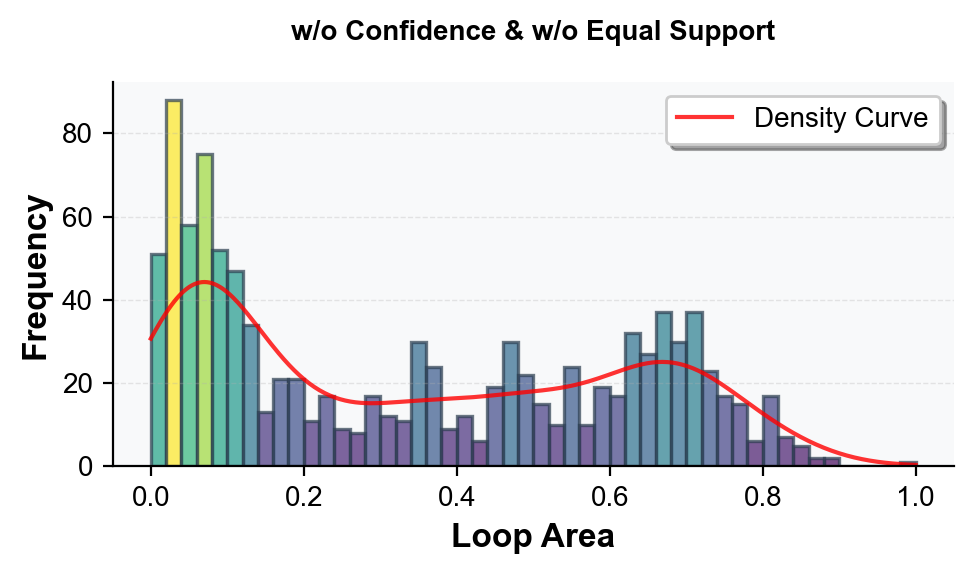

In [31]:
all_train_indices = []
for i in range (10):
    result = np.load (f'StatisticAnalysis/no_confidence_no_tie/rs_{i}_npp_1_step_49.npz')
    train_indices = result['train_indices']
    if i == 0:
        all_train_indices = train_indices
    else:
        all_train_indices = np.append(all_train_indices, train_indices)

train_loopareas = y_area[all_train_indices]

fig, ax = plt.subplots(figsize=(5, 3), dpi=200)

# Create histogram with improved styling
n, bins, patches = ax.hist(train_loopareas, bins=50, 
                           color='#3498db', 
                           alpha=0.7, 
                           edgecolor='#2c3e50', 
                           linewidth=1.2)

# Add a gradient effect to bars (optional but beautiful!)
# Color bars based on height
cm = plt.cm.viridis
norm = plt.Normalize(vmin=n.min(), vmax=n.max())
for i, patch in enumerate(patches):
    patch.set_facecolor(cm(norm(n[i])))

# Add a KDE curve overlay for smoothness
from scipy.stats import gaussian_kde
kde = gaussian_kde(train_loopareas)
x_range = np.linspace(train_loopareas.min(), train_loopareas.max(), 300)
kde_values = kde(x_range)

# Scale KDE to match histogram
kde_scaled = kde_values * len(train_loopareas) * (bins[1] - bins[0])
ax.plot(x_range, kde_scaled, 'r-', linewidth=1.5, 
        label='Density Curve', alpha=0.8)
ax.set_title('w/o Confidence & w/o Equal Support', 
             fontweight='bold', fontsize=10, pad=15)
# Styling
ax.set_xlabel('Loop Area', fontweight='bold', fontsize=12)
ax.set_ylabel('Frequency', fontweight='bold', fontsize=12)
ax.legend(fontsize=10, frameon=True, fancybox=True, shadow=True, loc='best')
ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_facecolor('#F8F9FA')

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

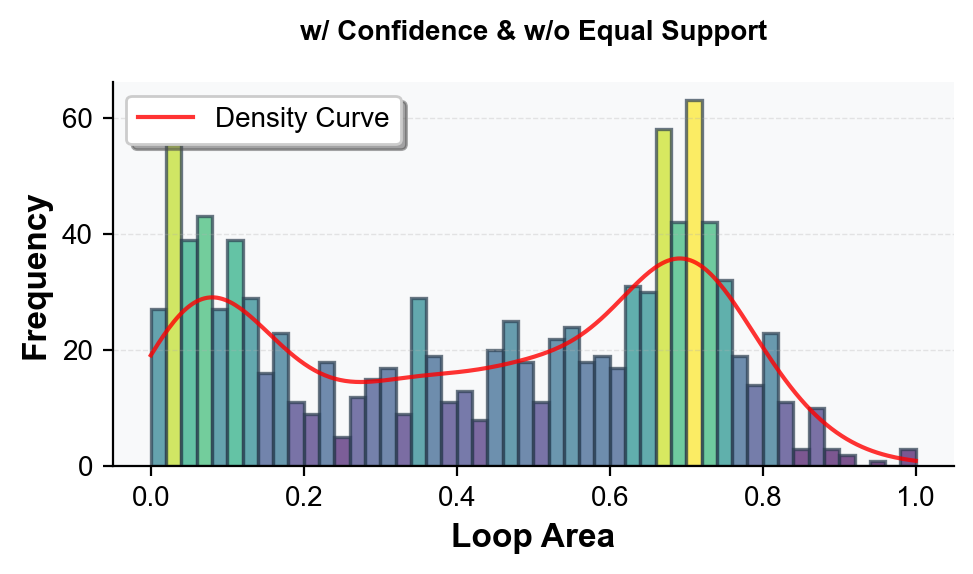

In [32]:
all_train_indices = []
for i in range (10):
    result = np.load (f'StatisticAnalysis/confidence_notie/rs_{i}_npp_1_step_49.npz')
    train_indices = result['train_indices']
    if i == 0:
        all_train_indices = train_indices
    else:
        all_train_indices = np.append(all_train_indices, train_indices)

train_loopareas = y_area[all_train_indices]

fig, ax = plt.subplots(figsize=(5, 3), dpi=200)

# Create histogram with improved styling
n, bins, patches = ax.hist(train_loopareas, bins=50, 
                           color='#3498db', 
                           alpha=0.7, 
                           edgecolor='#2c3e50', 
                           linewidth=1.2)

# Add a gradient effect to bars (optional but beautiful!)
# Color bars based on height
cm = plt.cm.viridis
norm = plt.Normalize(vmin=n.min(), vmax=n.max())
for i, patch in enumerate(patches):
    patch.set_facecolor(cm(norm(n[i])))

# Add a KDE curve overlay for smoothness
from scipy.stats import gaussian_kde
kde = gaussian_kde(train_loopareas)
x_range = np.linspace(train_loopareas.min(), train_loopareas.max(), 300)
kde_values = kde(x_range)

# Scale KDE to match histogram
kde_scaled = kde_values * len(train_loopareas) * (bins[1] - bins[0])
ax.plot(x_range, kde_scaled, 'r-', linewidth=1.5, 
        label='Density Curve', alpha=0.8)
ax.set_title('w/ Confidence & w/o Equal Support', 
             fontweight='bold', fontsize=10, pad=15)
# Styling
ax.set_xlabel('Loop Area', fontweight='bold', fontsize=12)
ax.set_ylabel('Frequency', fontweight='bold', fontsize=12)
ax.legend(frameon=True, fancybox=True, shadow=True, fontsize = 10, loc='best')
ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_facecolor('#F8F9FA')

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

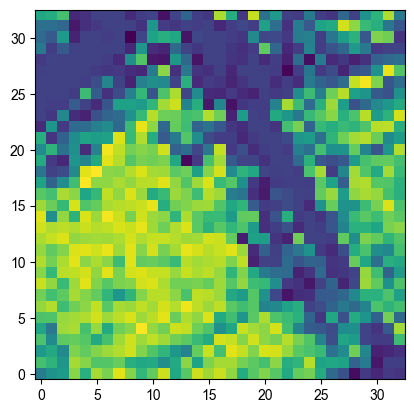

In [33]:
result = np.load ('StatisticAnalysis/confidence_tie/rs_0_npp_1_step_49.npz')
mean = result['mean']
plt.imshow(mean.reshape((psize, psize)), origin = 'lower')

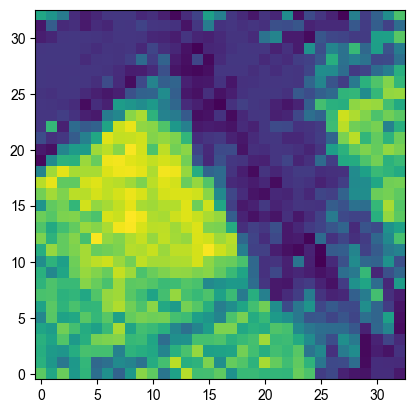

In [34]:
result = np.load ('StatisticAnalysis/confidence_tie_varnpp/rs_0_npp_3_step_49.npz')
mean = result['mean']
plt.imshow(mean.reshape((psize, psize)), origin = 'lower')

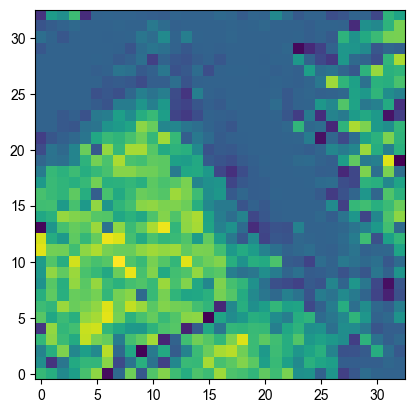

In [35]:
result = np.load ('StatisticAnalysis/confidence_tie_varnpp/rs_0_npp_5_step_49.npz')
mean = result['mean']
plt.imshow(mean.reshape((psize, psize)), origin = 'lower')

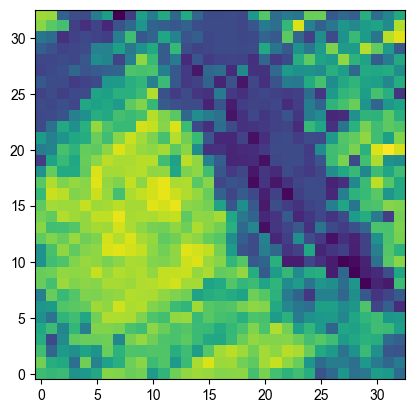

In [36]:
result = np.load ('StatisticAnalysis/confidence_tie_varnpp/rs_0_npp_8_step_49.npz')
mean = result['mean']
plt.imshow(mean.reshape((psize, psize)), origin = 'lower')

In [39]:
import numpy as np
from itertools import combinations
import random

def pairwise_ranking_comparison(data1, data2, tolerance=0.15, n_samples=None, seed=1):
    """
    Compare rankings using pairwise comparisons with tolerance.
    
    For each pair (Xi, Xj):
    - 0: Xi > Xj (clearly greater)
    - 1: Xi < Xj (clearly less)
    - 2: |Xi - Xj| <= tolerance (tie/similar)
    
    Parameters:
    -----------
    data1 : array-like
        First dataset
    data2 : array-like
        Second dataset
    tolerance : float
        Threshold for considering two values as similar
    n_samples : int, optional
        Number of random pairs to sample. If None, uses all pairs.
    seed : int, optional
        Random seed for reproducibility
        
    Returns:
    --------
    dict : Dictionary containing comparison results
    """
    data1 = np.array(data1)
    data2 = np.array(data2)
    
    if len(data1) != len(data2):
        raise ValueError("Datasets must have the same length")
    
    n = len(data1)
    
    # Generate all possible pairs or sample randomly
    all_pairs = list(combinations(range(n), 2))
    
    if n_samples is not None and n_samples < len(all_pairs):
        if seed is not None:
            random.seed(seed)
        pairs = random.sample(all_pairs, n_samples)
    else:
        pairs = all_pairs
    
    # Compare pairs
    comparisons_d1 = []
    comparisons_d2 = []
    pair_details = []
    
    for i, j in pairs:
        # Dataset 1 comparison
        diff1 = data1[i] - data1[j]
        if abs(diff1) <= tolerance:
            comp1 = 2  # tie
        elif diff1 > 0:
            comp1 = 0  # i > j
        else:
            comp1 = 1  # i < j
        
        # Dataset 2 comparison
        diff2 = data2[i] - data2[j]
        if abs(diff2) <= tolerance:
            comp2 = 2  # tie
        elif diff2 > 0:
            comp2 = 0  # i > j
        else:
            comp2 = 1  # i < j
        
        comparisons_d1.append(comp1)
        comparisons_d2.append(comp2)
        
        pair_details.append({
            'pair': (i, j),
            'values1': (data1[i], data1[j]),
            'values2': (data2[i], data2[j]),
            'comparison1': comp1,
            'comparison2': comp2,
            'match': comp1 == comp2
        })
    
    comparisons_d1 = np.array(comparisons_d1)
    comparisons_d2 = np.array(comparisons_d2)
    
    # Calculate agreement metrics
    exact_match = np.sum(comparisons_d1 == comparisons_d2)
    
    # Disagreement types
    disagreements = comparisons_d1 != comparisons_d2
    
    # Type 1: One says >, other says < (complete reversal, no tie involved)
    reversal = ((comparisons_d1 == 0) & (comparisons_d2 == 1)) | \
               ((comparisons_d1 == 1) & (comparisons_d2 == 0))
    
    # Type 2: One says tie (2), other says clear order (0 or 1)
    tie_conflict = ((comparisons_d1 == 2) & (comparisons_d2 != 2)) | \
                   ((comparisons_d1 != 2) & (comparisons_d2 == 2))
    
    # Strict agreement rate (exact matches)
    strict_agreement_rate = exact_match / len(pairs) * 100
    
    # Relaxed agreement rate (excluding tie conflicts as minor)
    relaxed_agreement = exact_match + np.sum(tie_conflict)
    relaxed_agreement_rate = relaxed_agreement / len(pairs) * 100
    
    return {
        'n_pairs': len(pairs),
        'exact_matches': exact_match,
        'reversals': np.sum(reversal),
        'tie_conflicts': np.sum(tie_conflict),
        'strict_agreement_rate': strict_agreement_rate,
        'relaxed_agreement_rate': relaxed_agreement_rate,
        'comparisons_d1': comparisons_d1,
        'comparisons_d2': comparisons_d2,
        'pair_details': pair_details}

In [40]:
# Load results of DKLPairWiseGP where no confidence weight and no tie are used
ncnt_fc_pr = []
ncnt_fcbn_pr = []
ncnt_resnet_pr = []
ncnt_attention_pr = []
for rs in range (5):
    for step in range (50):
        data1 = y_area
        result = np.load(f'Extractors/noconfidence_notie/fc_rs_{rs}_npp_1_step_{step}.npz')
        data2 = result['mean']
        comparison_result = pairwise_ranking_comparison(data1, data2, n_samples=1000)
        ncnt_fc_pr.append(comparison_result['strict_agreement_rate'])
        result = np.load(f'Extractors/noconfidence_notie/fcbn_rs_{rs}_npp_1_step_{step}.npz')
        data2 = result['mean']
        comparison_result = pairwise_ranking_comparison(data1, data2, n_samples=1000)   
        ncnt_fcbn_pr.append(comparison_result['strict_agreement_rate'])
        result = np.load(f'Extractors/noconfidence_notie/resnet_rs_{rs}_npp_1_step_{step}.npz')
        data2 = result['mean'] 
        comparison_result = pairwise_ranking_comparison(data1, data2, n_samples=1000)   
        ncnt_resnet_pr.append(comparison_result['strict_agreement_rate'])
        result = np.load(f'Extractors/noconfidence_notie/attention_rs_{rs}_npp_1_step_{step}.npz')
        data2 = result['mean'] 
        comparison_result = pairwise_ranking_comparison(data1, data2, n_samples=1000)   
        ncnt_attention_pr.append(comparison_result['strict_agreement_rate'])

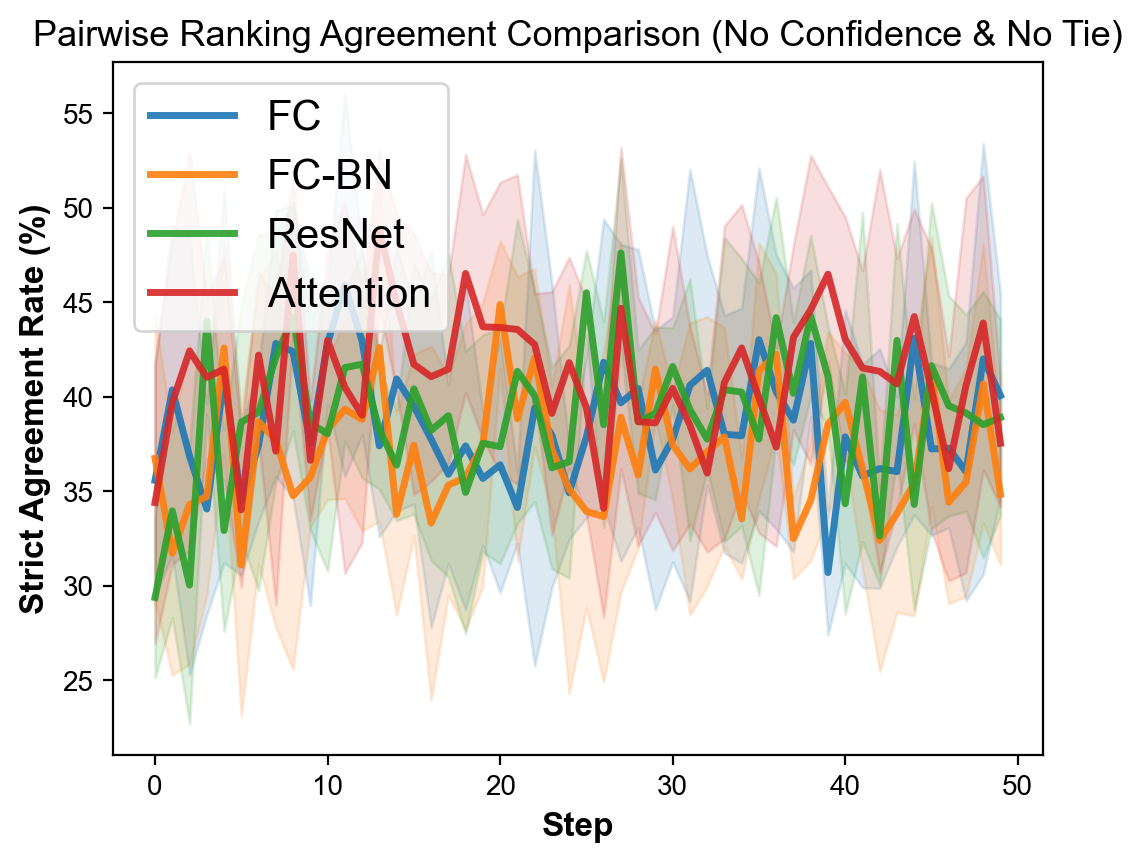

In [41]:
ncnt_fc_pr = np.array(ncnt_fc_pr).reshape((5, 50))
ncnt_fcbn_pr = np.array(ncnt_fcbn_pr).reshape((5, 50))
ncnt_resnet_pr = np.array(ncnt_resnet_pr).reshape((5, 50))
ncnt_attention_pr = np.array(ncnt_attention_pr).reshape((5, 50))

# Calculate means and standard deviations
mean_fc_ncnt = ncnt_fc_pr.mean(0)
std_fc_ncnt = ncnt_fc_pr.std(0)
mean_fcbn_ncnt = ncnt_fcbn_pr.mean(0)
std_fcbn_ncnt = ncnt_fcbn_pr.std(0)
mean_resnet_ncnt = ncnt_resnet_pr.mean(0)
std_resnet_ncnt = ncnt_resnet_pr.std(0)
mean_attention_ncnt = ncnt_attention_pr.mean(0)
std_attention_ncnt = ncnt_attention_pr.std(0)
# Create x-axis
x = np.arange(50)
fig, ax = plt.subplots(figsize=(6, 4.5), dpi=200)
# Modern color palette
colors = ['#1F77B4', '#FF7F0E', '#2CA02C', '#D62728']
labels = ['FC', 'FC-BN', 'ResNet', 'Attention'] 
# Data pairs
data_pair = [
    (mean_fc_ncnt, std_fc_ncnt),   
    (mean_fcbn_ncnt, std_fcbn_ncnt),   
    (mean_resnet_ncnt, std_resnet_ncnt),
    (mean_attention_ncnt, std_attention_ncnt)
]
# Plot each line with shaded region
for i, (mean_data, std_data) in enumerate(data_pair):
    # Main line (no markers)
    ax.plot(x, mean_data, 
            color=colors[i], 
            linewidth=2.5, 
            label=labels[i],
            alpha=0.9)
    
    # Shaded standard deviation
    ax.fill_between(x, 
                    mean_data - std_data, 
                    mean_data + std_data, 
                    color=colors[i], 
                    alpha=0.15)
# Styling
ax.set_xlabel('Step', fontweight='bold', fontsize=12)
ax.set_ylabel('Strict Agreement Rate (%)', fontweight='bold', fontsize=12)
ax.set_title('Pairwise Ranking Agreement Comparison (No Confidence & No Tie)')
# Enhanced legend
ax.legend(loc='upper left')


In [42]:
# Load results of DKLPairWiseGP where no confidence weight and no tie are used
nct_fc_pr = []
nct_fcbn_pr = []
nct_resnet_pr = []
nct_attention_pr = []
for rs in range (5):
    for step in range (50):
        data1 = y_area
        result = np.load(f'Extractors/noconfidence_tie/fc_rs_{rs}_npp_1_step_{step}.npz')
        data2 = result['mean']
        comparison_result = pairwise_ranking_comparison(data1, data2, n_samples=1000)
        nct_fc_pr.append(comparison_result['strict_agreement_rate'])
        result = np.load(f'Extractors/noconfidence_tie/fcbn_rs_{rs}_npp_1_step_{step}.npz')
        data2 = result['mean']
        comparison_result = pairwise_ranking_comparison(data1, data2, n_samples=1000)   
        nct_fcbn_pr.append(comparison_result['strict_agreement_rate'])
        result = np.load(f'Extractors/noconfidence_tie/resnet_rs_{rs}_npp_1_step_{step}.npz')
        data2 = result['mean'] 
        comparison_result = pairwise_ranking_comparison(data1, data2, n_samples=1000)   
        nct_resnet_pr.append(comparison_result['strict_agreement_rate'])
        result = np.load(f'Extractors/noconfidence_tie/attention_rs_{rs}_npp_1_step_{step}.npz')
        data2 = result['mean'] 
        comparison_result = pairwise_ranking_comparison(data1, data2, n_samples=1000)   
        nct_attention_pr.append(comparison_result['strict_agreement_rate'])

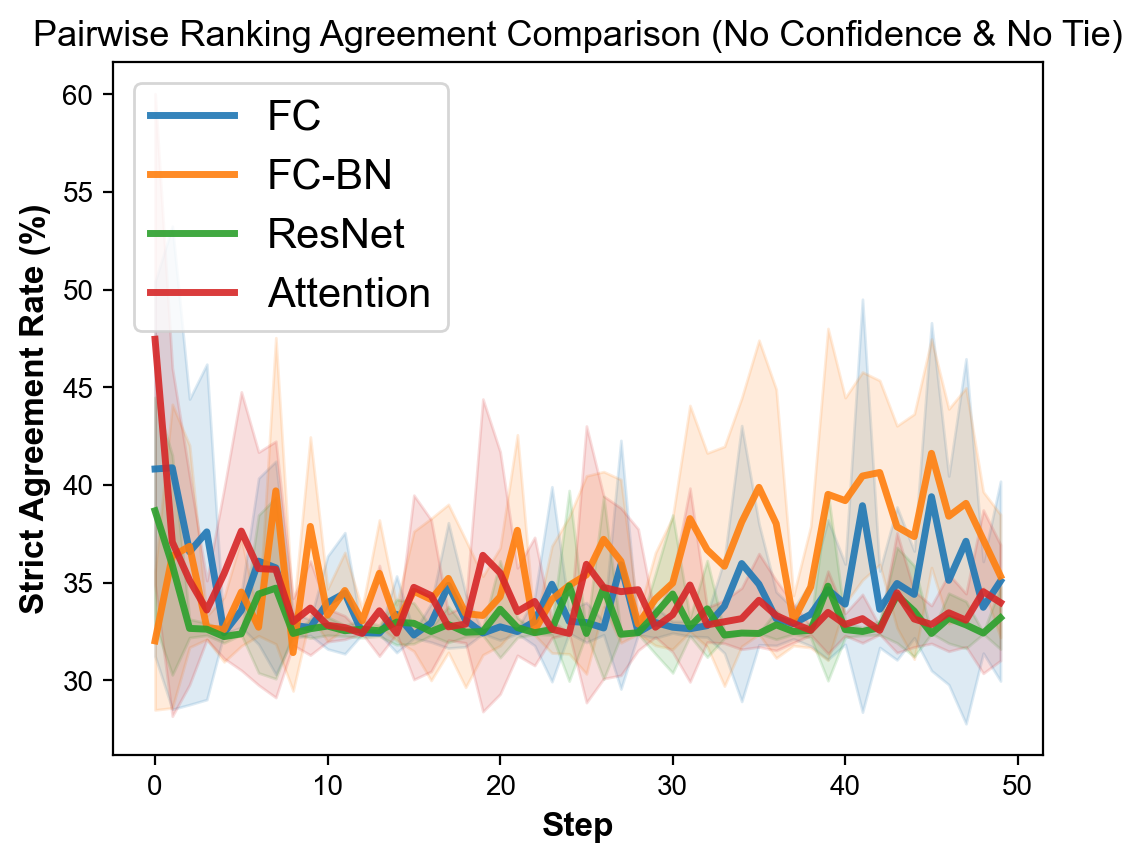

In [ ]:
nct_fc_pr = np.array(nct_fc_pr).reshape((5, 50))
nct_fcbn_pr = np.array(nct_fcbn_pr).reshape((5, 50))
nct_resnet_pr = np.array(nct_resnet_pr).reshape((5, 50))
nct_attention_pr = np.array(nct_attention_pr).reshape((5, 50))

# Calculate means and standard deviations
mean_fc_nct = nct_fc_pr.mean(0)
std_fc_nct = nct_fc_pr.std(0)
mean_fcbn_nct = nct_fcbn_pr.mean(0)
std_fcbn_nct = nct_fcbn_pr.std(0)
mean_resnet_nct = nct_resnet_pr.mean(0)
std_resnet_nct = nct_resnet_pr.std(0)
mean_attention_nct = nct_attention_pr.mean(0)
std_attention_nct = nct_attention_pr.std(0)
# Create x-axis
x = np.arange(50)
fig, ax = plt.subplots(figsize=(6, 4.5), dpi=200)
# Modern color palette
colors = ['#1F77B4', '#FF7F0E', '#2CA02C', '#D62728']
labels = ['FC', 'FC-BN', 'ResNet', 'Attention'] 
# Data pairs
data_pair = [
    (mean_fc_nct, std_fc_nct),   
    (mean_fcbn_nct, std_fcbn_nct),   
    (mean_resnet_nct, std_resnet_nct),
    (mean_attention_nct, std_attention_nct)
]
# Plot each line with shaded region
for i, (mean_data, std_data) in enumerate(data_pair):
    # Main line (no markers)
    ax.plot(x, mean_data, 
            color=colors[i], 
            linewidth=2.5, 
            label=labels[i],
            alpha=0.9)
    
    # Shaded standard deviation
    ax.fill_between(x, 
                    mean_data - std_data, 
                    mean_data + std_data, 
                    color=colors[i], 
                    alpha=0.15)
# Styling
ax.set_xlabel('Step', fontweight='bold', fontsize=12)
ax.set_ylabel('Strict Agreement Rate (%)', fontweight='bold', fontsize=12)
ax.set_title('Pairwise Ranking Agreement Comparison (No Confidence & Tie)')
# Enhanced legend
ax.legend(loc='upper left')

In [45]:
# Load results of DKLPairWiseGP where no confidence weight and no tie are used
cnt_fc_pr = []
cnt_fcbn_pr = []
cnt_resnet_pr = []
cnt_attention_pr = []
for rs in range (5):
    for step in range (50):
        data1 = y_area
        result = np.load(f'Extractors/confidence_notie/fc_rs_{rs}_npp_1_step_{step}.npz')
        data2 = result['mean']
        comparison_result = pairwise_ranking_comparison(data1, data2, n_samples=1000)
        cnt_fc_pr.append(comparison_result['strict_agreement_rate'])
        result = np.load(f'Extractors/confidence_notie/fcbn_rs_{rs}_npp_1_step_{step}.npz')
        data2 = result['mean']
        comparison_result = pairwise_ranking_comparison(data1, data2, n_samples=1000)   
        cnt_fcbn_pr.append(comparison_result['strict_agreement_rate'])
        result = np.load(f'Extractors/confidence_notie/resnet_rs_{rs}_npp_1_step_{step}.npz')
        data2 = result['mean'] 
        comparison_result = pairwise_ranking_comparison(data1, data2, n_samples=1000)   
        cnt_resnet_pr.append(comparison_result['strict_agreement_rate'])
        result = np.load(f'Extractors/confidence_notie/attention_rs_{rs}_npp_1_step_{step}.npz')
        data2 = result['mean'] 
        comparison_result = pairwise_ranking_comparison(data1, data2, n_samples=1000)   
        cnt_attention_pr.append(comparison_result['strict_agreement_rate'])

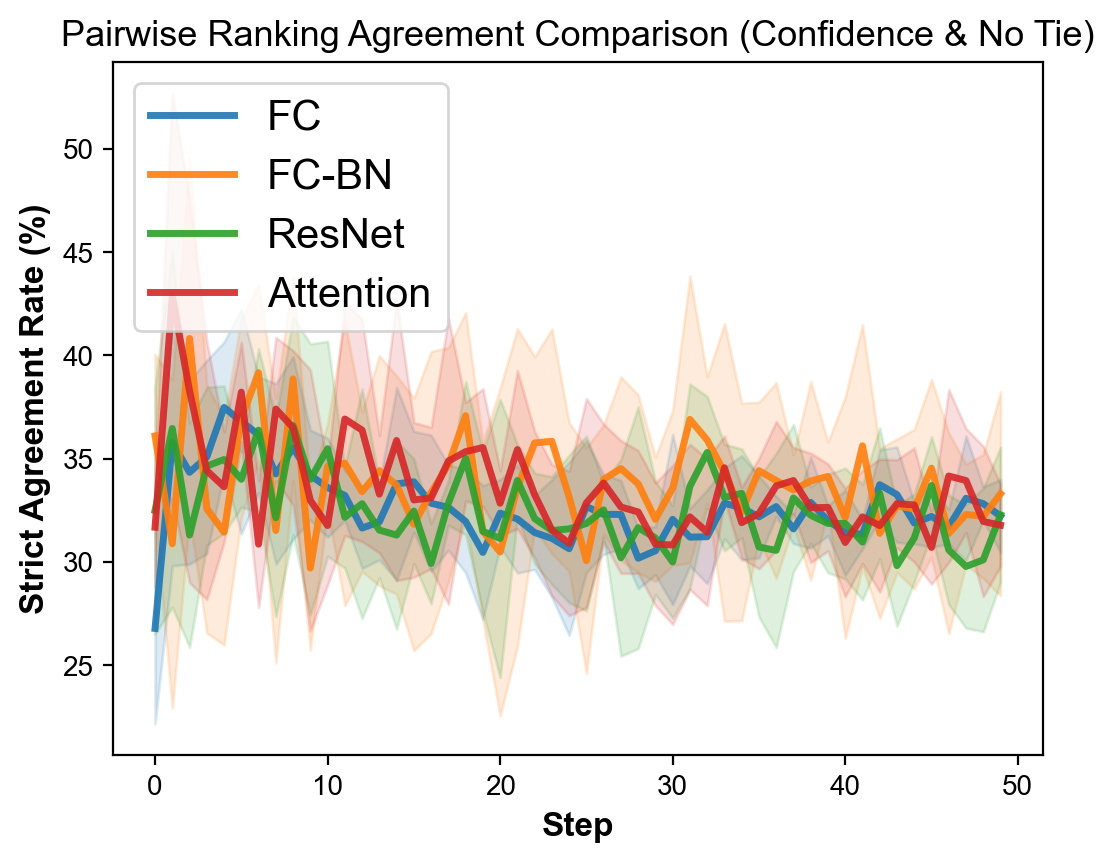

In [46]:
cnt_fc_pr = np.array(cnt_fc_pr).reshape((5, 50))
cnt_fcbn_pr = np.array(cnt_fcbn_pr).reshape((5, 50))
cnt_resnet_pr = np.array(cnt_resnet_pr).reshape((5, 50))
cnt_attention_pr = np.array(cnt_attention_pr).reshape((5, 50))

# Calculate means and standard deviations
mean_fc_cnt = cnt_fc_pr.mean(0)
std_fc_cnt = cnt_fc_pr.std(0)
mean_fcbn_cnt = cnt_fcbn_pr.mean(0)
std_fcbn_cnt = cnt_fcbn_pr.std(0)
mean_resnet_cnt = cnt_resnet_pr.mean(0)
std_resnet_cnt = cnt_resnet_pr.std(0)
mean_attention_cnt = cnt_attention_pr.mean(0)
std_attention_cnt = cnt_attention_pr.std(0)
# Create x-axis
x = np.arange(50)
fig, ax = plt.subplots(figsize=(6, 4.5), dpi=200)
# Modern color palette
colors = ['#1F77B4', '#FF7F0E', '#2CA02C', '#D62728']
labels = ['FC', 'FC-BN', 'ResNet', 'Attention'] 
# Data pairs
data_pair = [
    (mean_fc_cnt, std_fc_cnt),   
    (mean_fcbn_cnt, std_fcbn_cnt),   
    (mean_resnet_cnt, std_resnet_cnt),
    (mean_attention_cnt, std_attention_cnt)
]
# Plot each line with shaded region
for i, (mean_data, std_data) in enumerate(data_pair):
    # Main line (no markers)
    ax.plot(x, mean_data, 
            color=colors[i], 
            linewidth=2.5, 
            label=labels[i],
            alpha=0.9)
    
    # Shaded standard deviation
    ax.fill_between(x, 
                    mean_data - std_data, 
                    mean_data + std_data, 
                    color=colors[i], 
                    alpha=0.15)
# Styling
ax.set_xlabel('Step', fontweight='bold', fontsize=12)
ax.set_ylabel('Strict Agreement Rate (%)', fontweight='bold', fontsize=12)
ax.set_title('Pairwise Ranking Agreement Comparison (Confidence & No Tie)')
# Enhanced legend
ax.legend(loc='upper left')

In [47]:
# Load results of DKLPairWiseGP where no confidence weight and no tie are used
ct_fc_pr = []
ct_fcbn_pr = []
ct_resnet_pr = []
ct_attention_pr = []
for rs in range (5):
    for step in range (50):
        data1 = y_area
        result = np.load(f'Extractors/confidence_tie/fc_rs_{rs}_npp_1_step_{step}.npz')
        data2 = result['mean']
        comparison_result = pairwise_ranking_comparison(data1, data2, n_samples=1000)
        ct_fc_pr.append(comparison_result['strict_agreement_rate'])
        result = np.load(f'Extractors/confidence_tie/fcbn_rs_{rs}_npp_1_step_{step}.npz')
        data2 = result['mean']
        comparison_result = pairwise_ranking_comparison(data1, data2, n_samples=1000)   
        ct_fcbn_pr.append(comparison_result['strict_agreement_rate'])
        result = np.load(f'Extractors/confidence_tie/resnet_rs_{rs}_npp_1_step_{step}.npz')
        data2 = result['mean'] 
        comparison_result = pairwise_ranking_comparison(data1, data2, n_samples=1000)   
        ct_resnet_pr.append(comparison_result['strict_agreement_rate'])
        result = np.load(f'Extractors/confidence_tie/attention_rs_{rs}_npp_1_step_{step}.npz')
        data2 = result['mean'] 
        comparison_result = pairwise_ranking_comparison(data1, data2, n_samples=1000)   
        ct_attention_pr.append(comparison_result['strict_agreement_rate'])

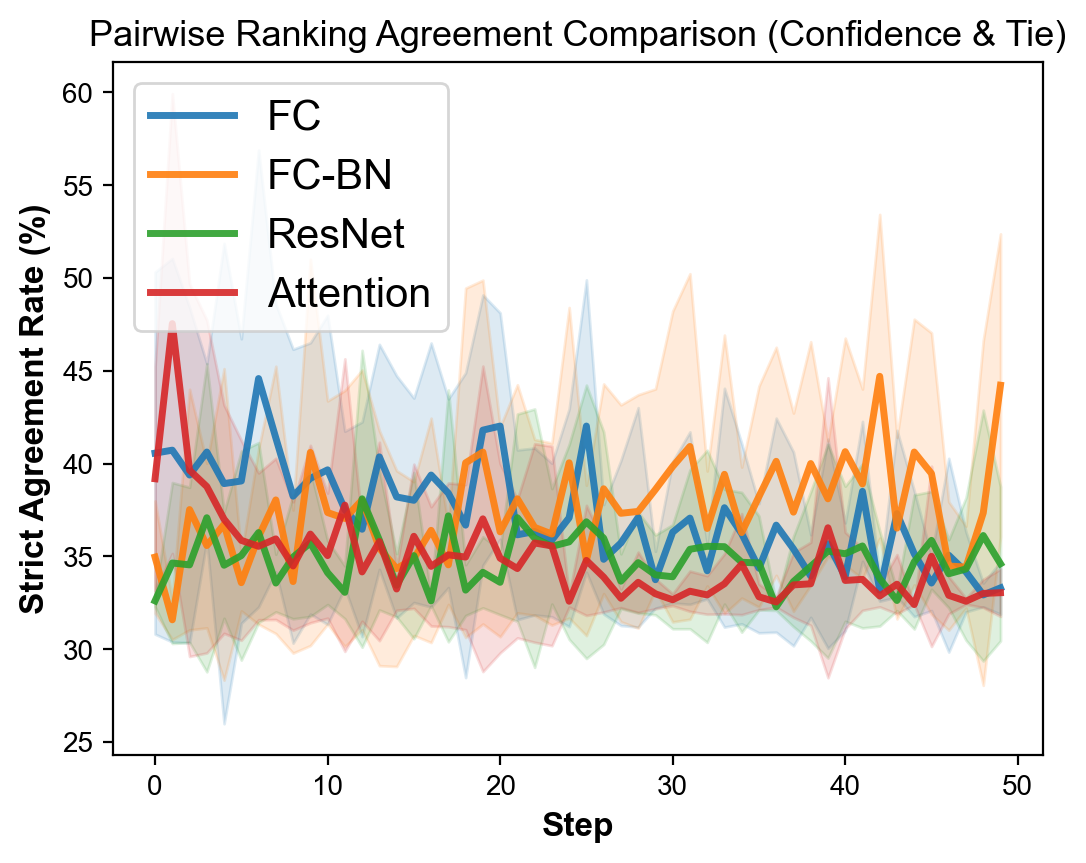

In [48]:
ct_fc_pr = np.array(ct_fc_pr).reshape((5, 50))
ct_fcbn_pr = np.array(ct_fcbn_pr).reshape((5, 50))
ct_resnet_pr = np.array(ct_resnet_pr).reshape((5, 50))
ct_attention_pr = np.array(ct_attention_pr).reshape((5, 50))

# Calculate means and standard deviations
mean_fc_ct = ct_fc_pr.mean(0)
std_fc_ct = ct_fc_pr.std(0)
mean_fcbn_ct = ct_fcbn_pr.mean(0)
std_fcbn_ct = ct_fcbn_pr.std(0)
mean_resnet_ct = ct_resnet_pr.mean(0)
std_resnet_ct = ct_resnet_pr.std(0)
mean_attention_ct = ct_attention_pr.mean(0)
std_attention_ct = ct_attention_pr.std(0)
# Create x-axis
x = np.arange(50)
fig, ax = plt.subplots(figsize=(6, 4.5), dpi=200)
# Modern color palette
colors = ['#1F77B4', '#FF7F0E', '#2CA02C', '#D62728']
labels = ['FC', 'FC-BN', 'ResNet', 'Attention'] 
# Data pairs
data_pair = [
    (mean_fc_ct, std_fc_ct),   
    (mean_fcbn_ct, std_fcbn_ct),   
    (mean_resnet_ct, std_resnet_ct),
    (mean_attention_ct, std_attention_ct)
]
# Plot each line with shaded region
for i, (mean_data, std_data) in enumerate(data_pair):
    # Main line (no markers)
    ax.plot(x, mean_data, 
            color=colors[i], 
            linewidth=2.5, 
            label=labels[i],
            alpha=0.9)
    
    # Shaded standard deviation
    ax.fill_between(x, 
                    mean_data - std_data, 
                    mean_data + std_data, 
                    color=colors[i], 
                    alpha=0.15)
# Styling
ax.set_xlabel('Step', fontweight='bold', fontsize=12)
ax.set_ylabel('Strict Agreement Rate (%)', fontweight='bold', fontsize=12)
ax.set_title('Pairwise Ranking Agreement Comparison (Confidence & Tie)')
# Enhanced legend
ax.legend(loc='upper left')